# 07 — Combos, reduced: reliability, nine headline tests, mixed models, turn and event grains

The 2,560-cell map (notebooks 03–06) is Holm/BH-null everywhere. This notebook asks the questions that map cannot: **how reliable are the person-level scores being correlated** (block 0), **what does one score per modality say** (block 1), **what do the a-priori cells look like with intervals** (block 2), **does EEG state moderate the behavioural effect within person** (block 3), **does genre movement relate to process at the turn grain** (block 4), **does the onset-locked EEG response to an ad predict recall, genre shift or the next turn** (block 5), **do the modalities order the five conditions alike** (block 6), and **does the one EEG quantity that works here (write − read Fz \(\theta\)) predict the behavioural ad effect as a trait** (block 7).

Person is the inferential unit throughout. Every family is Holm-corrected within itself, BH across its table, and the model families carry a Freedman–Lane max-\(|t|\) permutation with persons as exchangeability blocks. Scripts: `run_reliability.py`, `run_headline.py`, `run_forest.py`, `run_lmm.py`, `run_turns.py`, `run_events.py`, `run_concordance.py`, `run_task_state.py`, `summarise_blocks.py`.

**Result in one line: 336 new tests, 0 Holm, 0 BH (within table and pooled over the 336, and pooled with the 2,560-cell map), 10 raw hits where 17 are expected under the null; every family-wise permutation \(p > .23\).** The informative output is block 0: the Fz \(\theta\) \(D_i\) at \(k=37\) have no *detectable* between-person reliability (point estimates 0.00–0.01, 18-person upper bounds ≈ .64; .35–.61 with all ~95 tiles), the trajectory \(D_i\) barely agree across the two genre classifiers, and at \(n=18\) a Spearman needs \(|\rho| > .47\) to reach raw .05.

In [1]:
from pathlib import Path
import json, sys, warnings
warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, display, Markdown

HERE = Path.cwd().resolve()
while not (HERE / "analysis" / "walter" / "statkit.py").exists():
    HERE = HERE.parent
OUT = HERE / "analysis" / "walter" / "combos" / "outputs"
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200); pd.set_option("display.max_rows", 200)
def show(p, w=1100):
    display(Image(filename=str(OUT / p), width=w))
def js(p):
    return json.loads((OUT / p).read_text())


## Ledger

In [2]:
L = pd.read_csv(OUT / "blocks_ledger.csv")
display(L.drop(columns="source").round(4))
S = js("blocks_summary.json")
display(Markdown(f"**Map:** {S['map_tests']} tests. **Blocks 1–7:** {S['new_tests_blocks_1_7']} tests, {S['new_hits_raw']} raw hits (expected {S['expected_raw_hits_under_null']:.1f}), {S['new_hits_holm']} Holm, {S['new_hits_bh_within_table']} BH within table, {S['new_hits_bh_pooled']} BH pooled over {S['n_pooled_new']}, {S['all_hits_bh_pooled_blocks_plus_map']} BH pooled over {S['n_pooled_all']} (blocks + map)."))
display(pd.Series(S["familywise_permutation_p"], name="Freedman-Lane family-wise p").round(3))

,block,family,n_tests,min_p_raw,hits_raw,hits_holm_family,hits_bh_global_in_table,p_perm_familywise
0,map (run_combos),beh_eeg|D,720,0.0014,33,0,0,NaN
1,map (run_combos),beh_eeg|RM,240,0.0027,11,0,0,NaN
2,map (run_combos),beh_traj|D,450,0.0046,15,0,0,NaN
3,map (run_combos),beh_traj|RM,150,0.0097,15,0,0,NaN
4,map (run_combos),threeway|D,360,0.0081,21,0,0,NaN
5,map (run_combos),traj_eeg|D,480,0.0063,10,0,0,NaN
6,map (run_combos),traj_eeg|RM,160,0.0645,0,0,0,NaN
7,1 headline PC1,headline_PC1,9,0.0630,0,0,0,NaN
8,1 headline PC1,planned_primaries,12,0.2574,0,0,0,NaN
9,1 headline PC1,process_PC1,9,0.0724,0,0,0,NaN


**Map:** 2560 tests. **Blocks 1–7:** 336 tests, 10 raw hits (expected 16.8), 0 Holm, 0 BH within table, 0 BH pooled over 336, 0 BH pooled over 2896 (blocks + map).

A_state_association       0.690
B0_main_within_ads        0.737
B_moderation              0.894
events_all_exploratory    0.355
events_headline           0.234
Name: Freedman-Lane family-wise p, dtype: float64

## Block 0 — what is being correlated, and how reliable it is

Split-half over the 37 tiles of each Dataset A \(k=37\) cell (random halves, 200 draws, Spearman–Brown = upper bound; first vs second half = lower bound, confounded with drift). Reliability of a \(D_i\) is the corrected correlation of the two half-\(D\)'s across the 18 people. Behavioural composite \(D_i\): Cronbach \(\alpha\) of the item-level \(D\)'s. Trajectory: agreement of \(D_i\) between the utterance and contextual genre classifiers (no Spearman–Brown; parallel forms, not halves).

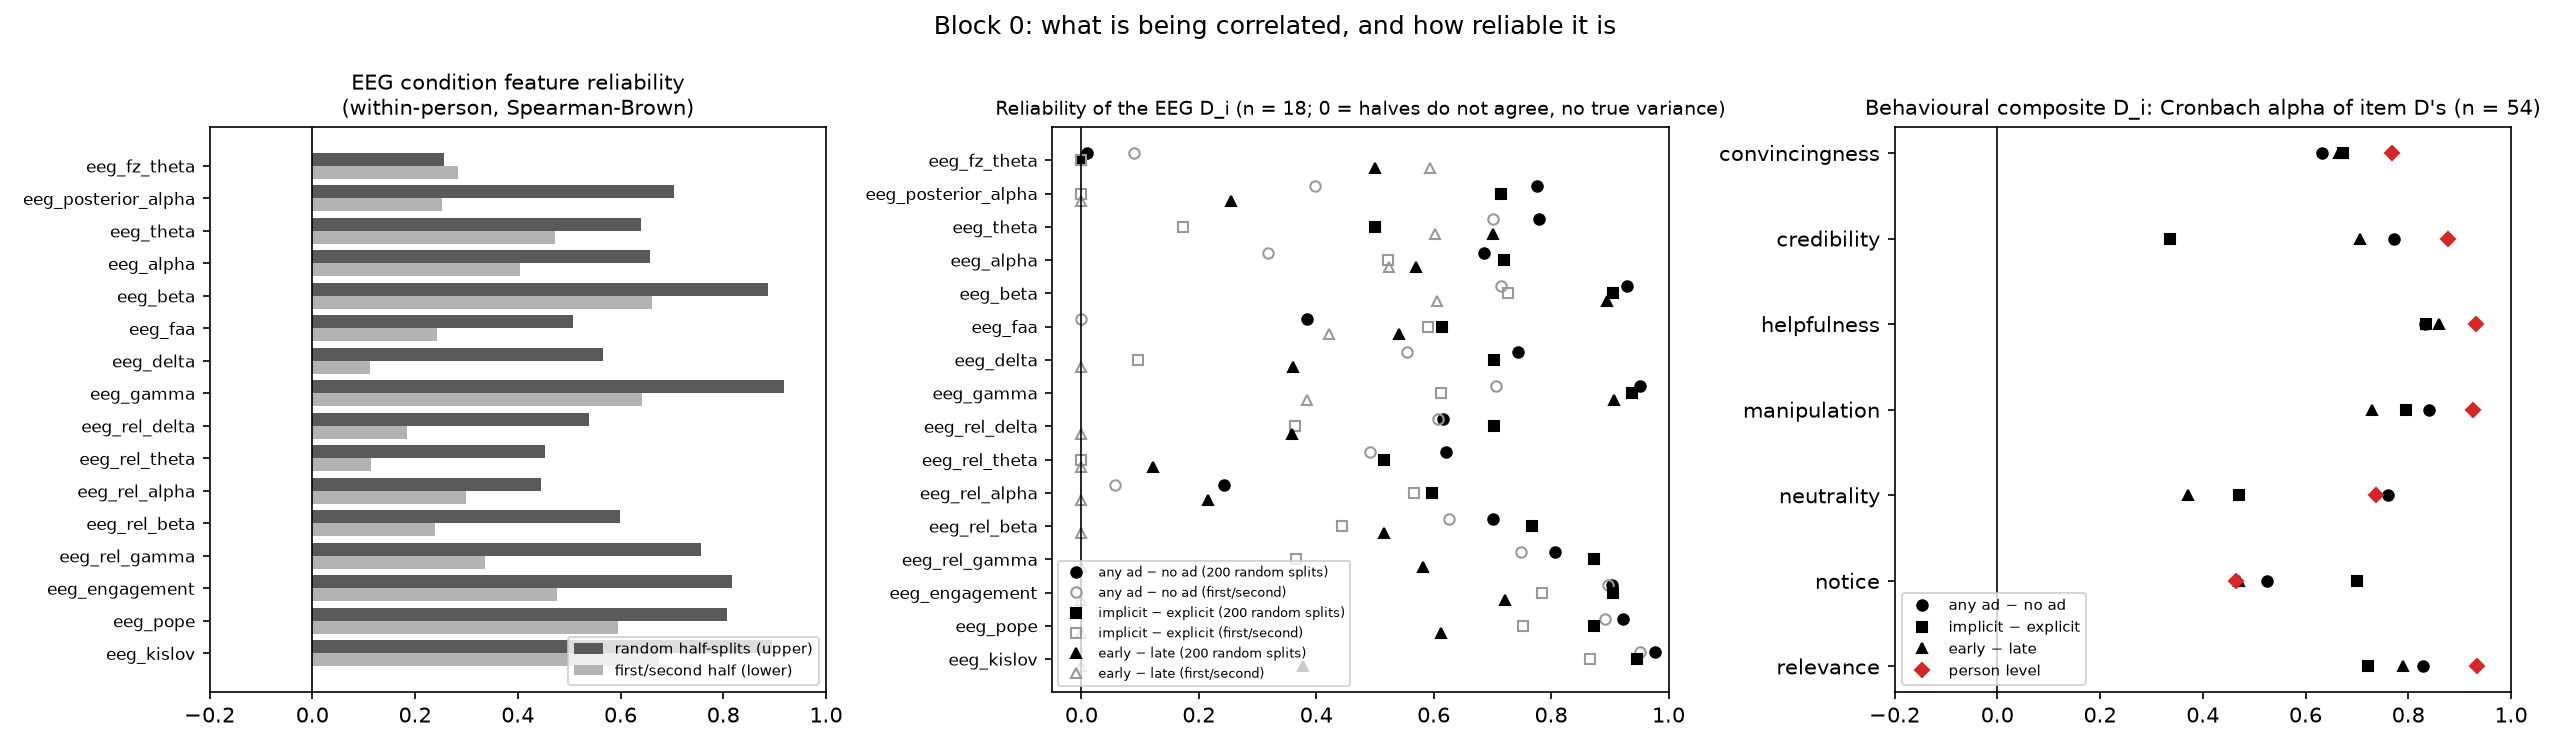

Median within-person reliability of an EEG condition feature: random halves **0.65**, first/second **0.32**. Median \(D_i\) reliability: **0.70** / **0.43**.

contrast,any_ad_vs_no_ads,early_vs_late,inline_vs_block,pair_inline_early_minus_block_late
feature,,,,
eeg_alpha,0.69,0.57,0.72,0.58
eeg_beta,0.93,0.89,0.90,0.93
eeg_delta,0.74,0.36,0.70,0.43
eeg_engagement,0.90,0.72,0.91,0.87
eeg_faa,0.38,0.54,0.61,0.60
eeg_fz_theta,0.01,0.50,0.00,0.00
eeg_gamma,0.95,0.91,0.94,0.94
eeg_kislov,0.98,0.38,0.95,0.90
eeg_pope,0.92,0.61,0.87,0.79


,scheme,feature,contrast,r_halves,r_halves_ci_lo,r_halves_ci_hi,rel_D_SB,rel_D_SB_ci_hi
148,random,eeg_fz_theta,any_ad_vs_no_ads,0.00,-0.46,0.47,0.01,0.64
149,random,eeg_fz_theta,early_vs_late,0.33,-0.16,0.69,0.50,0.82
150,random,eeg_fz_theta,inline_vs_block,0.00,-0.47,0.47,0.00,0.64
151,random,eeg_fz_theta,pair_inline_early_minus_block_late,-0.14,-0.57,0.35,0.00,0.52
164,random,eeg_posterior_alpha,any_ad_vs_no_ads,0.63,0.24,0.85,0.78,0.92
165,random,eeg_posterior_alpha,early_vs_late,0.15,-0.34,0.57,0.25,0.73
166,random,eeg_posterior_alpha,inline_vs_block,0.56,0.12,0.81,0.71,0.90
167,random,eeg_posterior_alpha,pair_inline_early_minus_block_late,0.36,-0.13,0.71,0.53,0.83
212,random_all_tiles,eeg_fz_theta,any_ad_vs_no_ads,0.29,-0.21,0.66,0.45,0.80
213,random_all_tiles,eeg_fz_theta,early_vs_late,0.44,-0.03,0.75,0.61,0.86


In [3]:
show("reliability/reliability.png", 1200)
R = js("reliability/summary.json")
display(Markdown(f"Median within-person reliability of an EEG condition feature: random halves **{R['eeg_feature_rel_within_SB_median']['random']:.2f}**, first/second **{R['eeg_feature_rel_within_SB_median']['first_second']:.2f}**. Median \(D_i\) reliability: **{R['eeg_D_rel_median']['random']:.2f}** / **{R['eeg_D_rel_median']['first_second']:.2f}**."))
d = pd.read_csv(OUT / "reliability/eeg_D_reliability.csv")
display(d[d.scheme == "random"].pivot(index="feature", columns="contrast", values="rel_D_SB").round(2))
display(d[d.feature.isin(["eeg_fz_theta", "eeg_posterior_alpha"]) & d.scheme.isin(["random", "random_all_tiles"])][["scheme", "feature", "contrast", "r_halves", "r_halves_ci_lo", "r_halves_ci_hi", "rel_D_SB", "rel_D_SB_ci_hi"]].round(2))

Fz \(\theta\) — the primary feature — is the least reliable condition feature at \(k=37\) (0.26; 0.46 with all tiles) and its any-ad and format \(D_i\) have no *detectable* true variance (point estimates 0.01, 0.00; the 18-person sampling interval puts the Spearman–Brown upper bound at ≈ .64). With every retained tile (~95, the whole-window Gold aggregation) those rise to .45 and .35: \(k=37\) costs reliability on the single-channel feature. Posterior \(\alpha\) any-ad \(D\) is 0.78 (0.82 whole-window). The post-hoc Dataset A cell (implicit-early − explicit-late Fz \(\theta\)) has pair-\(D\) reliability 0 at \(k=37\) under every split (upper bound .52) and .47 whole-window: a mean shift with little detectable between-person heterogeneity.

,metric,n_people,r_level_utterance_vs_contextual,note,r_D_any_ad_vs_no_ads,r_D_inline_vs_block,r_D_early_vs_late
0,traj_n_shift,54,0.32,NaN,-0.03,0.26,-0.03
1,traj_shift_rate,54,0.32,NaN,-0.02,0.25,-0.03
2,traj_diversity,54,0.21,NaN,0.01,0.25,-0.13
3,traj_entropy_nats,54,0.26,NaN,0.02,0.27,-0.12
4,traj_entropy_normalised,54,0.25,NaN,0.01,0.29,-0.11
5,traj_max_persistence,54,0.34,NaN,-0.07,0.30,0.02
6,traj_mean_js_divergence,54,-0.04,NaN,0.19,0.23,0.13
7,traj_max_js_divergence,54,-0.06,NaN,-0.05,0.13,0.20
8,traj_mean_total_variation,54,0.09,NaN,0.32,0.28,0.10
9,traj_shifted_into_purchasable,54,NaN,contextual source constant (never fires); agre...,NaN,NaN,NaN


contrast,any_ad_vs_no_ads,early_vs_late,inline_vs_block,level
composite,,,,
convincingness,0.63,0.67,0.67,0.77
credibility,0.77,0.71,0.34,0.88
helpfulness,0.83,0.86,0.84,0.93
manipulation,0.84,0.73,0.80,0.93
neutrality,0.76,0.37,0.47,0.74
notice,0.52,0.47,0.70,0.47
relevance,0.83,0.79,0.72,0.93


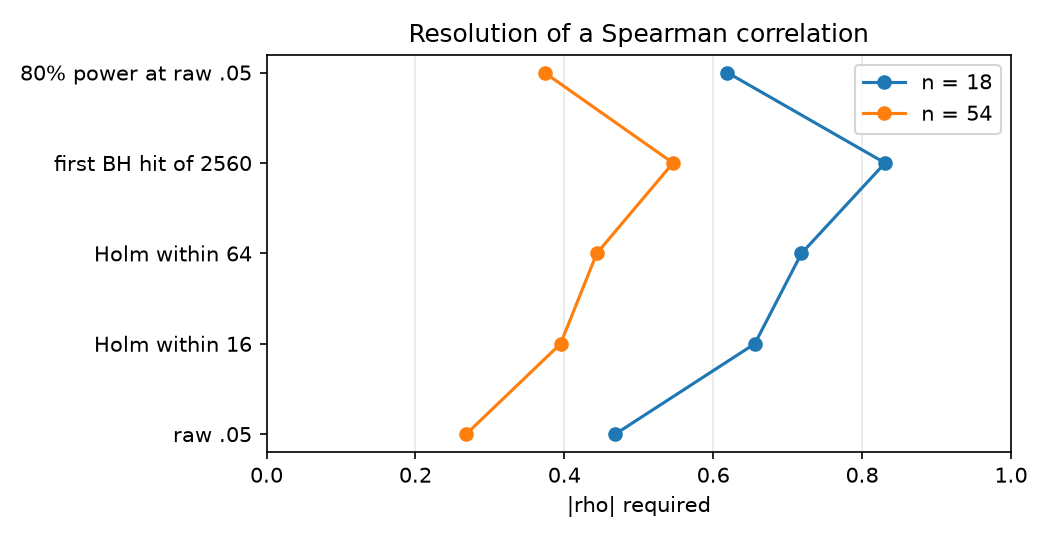

,contrast,behaviour,eeg,rel_beh_alpha,rel_eeg_D_k37_random,rel_eeg_D_k37_first_second,rel_eeg_D_all_tiles,max_observable_rho_k37_random,max_observable_rho_k37_first_second,max_observable_rho_all_tiles,max_observable_rho_best,true_rho_needed_raw05_n18_best,true_rho_needed_holm16_n18_best
0,any_ad_vs_no_ads,credibility,eeg_fz_theta,0.77,0.01,0.09,0.45,0.09,0.26,0.59,0.59,0.80,1.12
1,any_ad_vs_no_ads,manipulation,eeg_fz_theta,0.84,0.01,0.09,0.45,0.09,0.27,0.61,0.61,0.77,1.08
2,any_ad_vs_no_ads,notice,eeg_fz_theta,0.52,0.01,0.09,0.45,0.07,0.22,0.48,0.48,0.97,1.37
3,any_ad_vs_no_ads,credibility,eeg_posterior_alpha,0.77,0.78,0.40,0.82,0.77,0.55,0.80,0.80,0.59,0.83
4,any_ad_vs_no_ads,manipulation,eeg_posterior_alpha,0.84,0.78,0.40,0.82,0.81,0.58,0.83,0.83,0.57,0.80
5,any_ad_vs_no_ads,notice,eeg_posterior_alpha,0.52,0.78,0.40,0.82,0.64,0.46,0.66,0.66,0.72,1.01
6,inline_vs_block,credibility,eeg_fz_theta,0.34,0.00,0.00,0.35,0.01,0.00,0.34,0.34,1.37,1.92
7,inline_vs_block,manipulation,eeg_fz_theta,0.80,0.00,0.00,0.35,0.01,0.00,0.53,0.53,0.89,1.25
8,inline_vs_block,notice,eeg_fz_theta,0.70,0.00,0.00,0.35,0.01,0.00,0.50,0.50,0.95,1.33
9,inline_vs_block,credibility,eeg_posterior_alpha,0.34,0.71,0.00,0.62,0.49,0.00,0.46,0.49,0.96,1.35


In [4]:
display(pd.read_csv(OUT / "reliability/trajectory_D_source_agreement.csv").round(2))
display(pd.read_csv(OUT / "reliability/behavioural_D_alpha.csv").pivot(index="composite", columns="contrast", values="alpha").round(2))
show("reliability/resolution.png", 700)
display(pd.read_csv(OUT / "reliability/attenuation_ceiling_headline.csv").round(2))

The attenuation table is the punchline, read at its most favourable column (`max_observable_rho_best`, which is the whole-window reliability for every Fz \(\theta\) cell): for Fz \(\theta\) any-ad or format the largest *observable* Spearman with a behavioural composite is 0.34–0.61 (0.00–0.27 with the \(k=37\) reliabilities), so a raw-.05 hit at \(n=18\) needed a **true** \(\rho \ge 0.77\) and a Holm-within-16 hit needed a true \(\rho > 1\), i.e. was unreachable. Posterior \(\alpha\) any-ad is the best-placed pair: raw .05 needs a true \(\rho \ge 0.57\)–0.72, Holm-16 \(\ge 0.80\).

## Block 1 — one score per modality per contrast (9 tests)

PC1 of the z-scored \(D_i\) block per modality (behaviour: 8 survey composites → a negative-evaluation factor; trajectory: 10 metrics → a movement factor; EEG: 16 features → the slow-vs-fast spectral tilt). Behaviour × trajectory \(n=54\); anything with EEG \(n=18\).

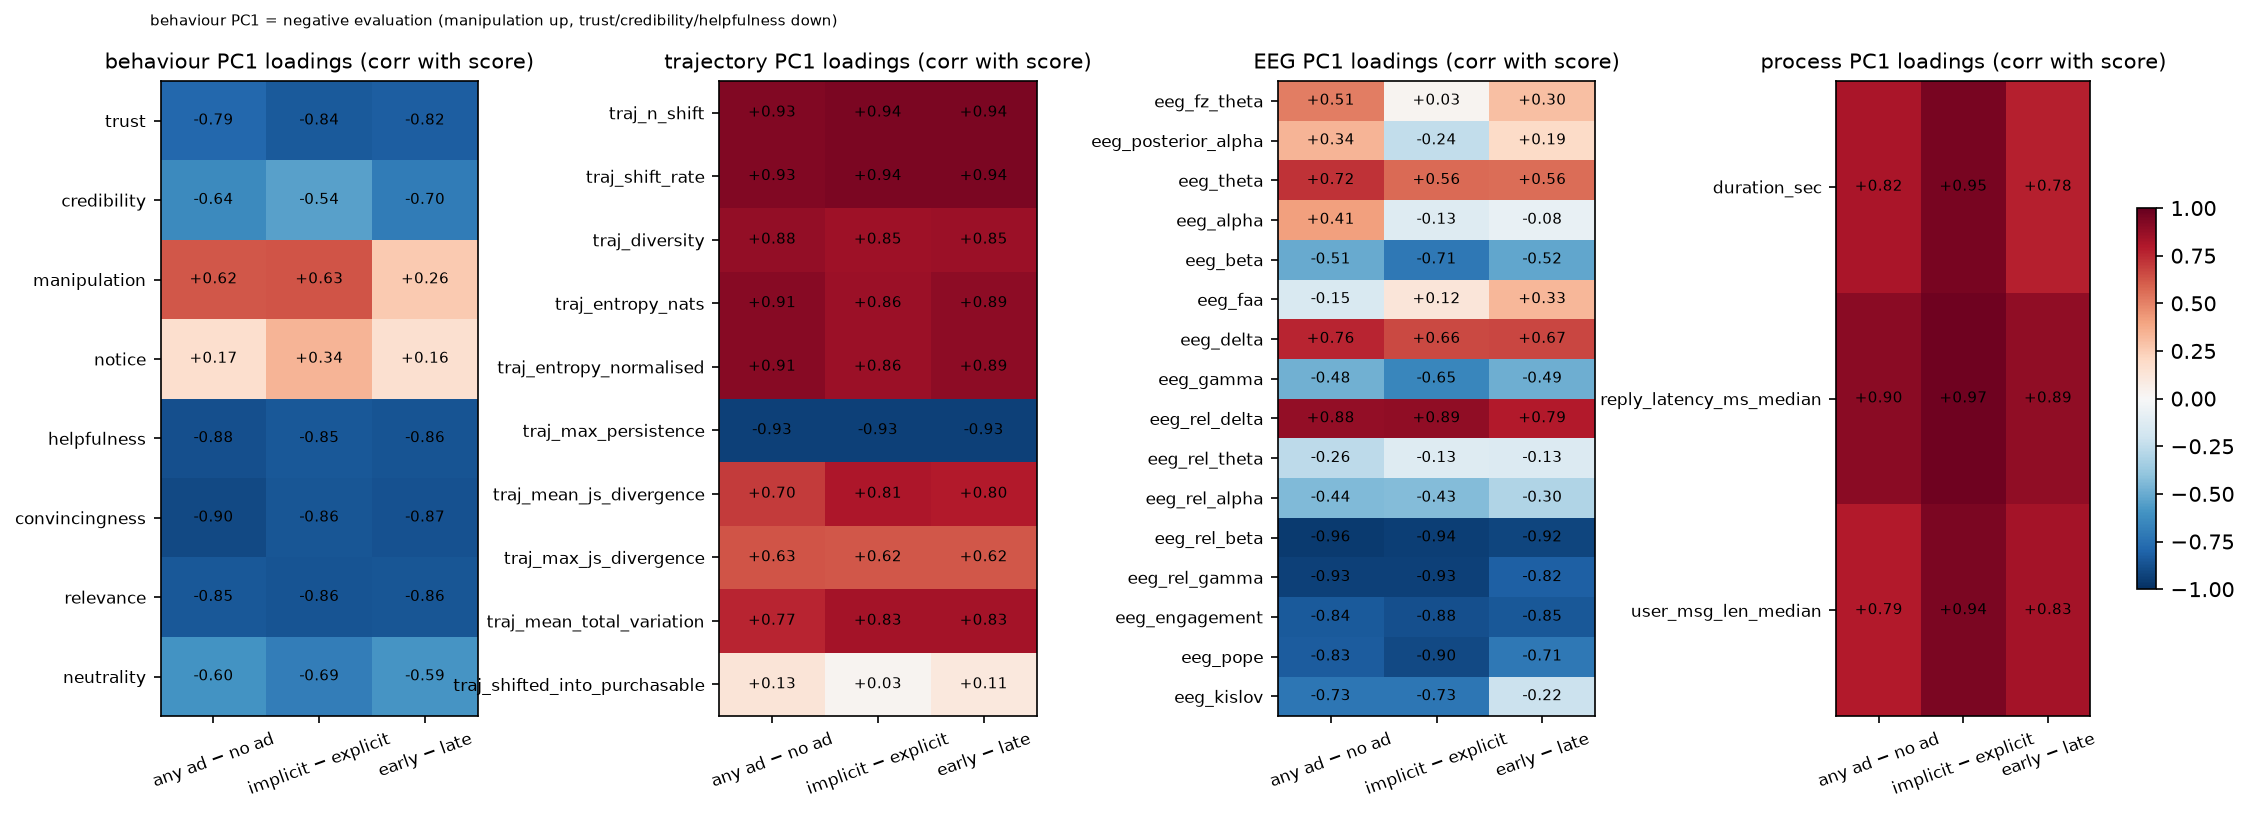

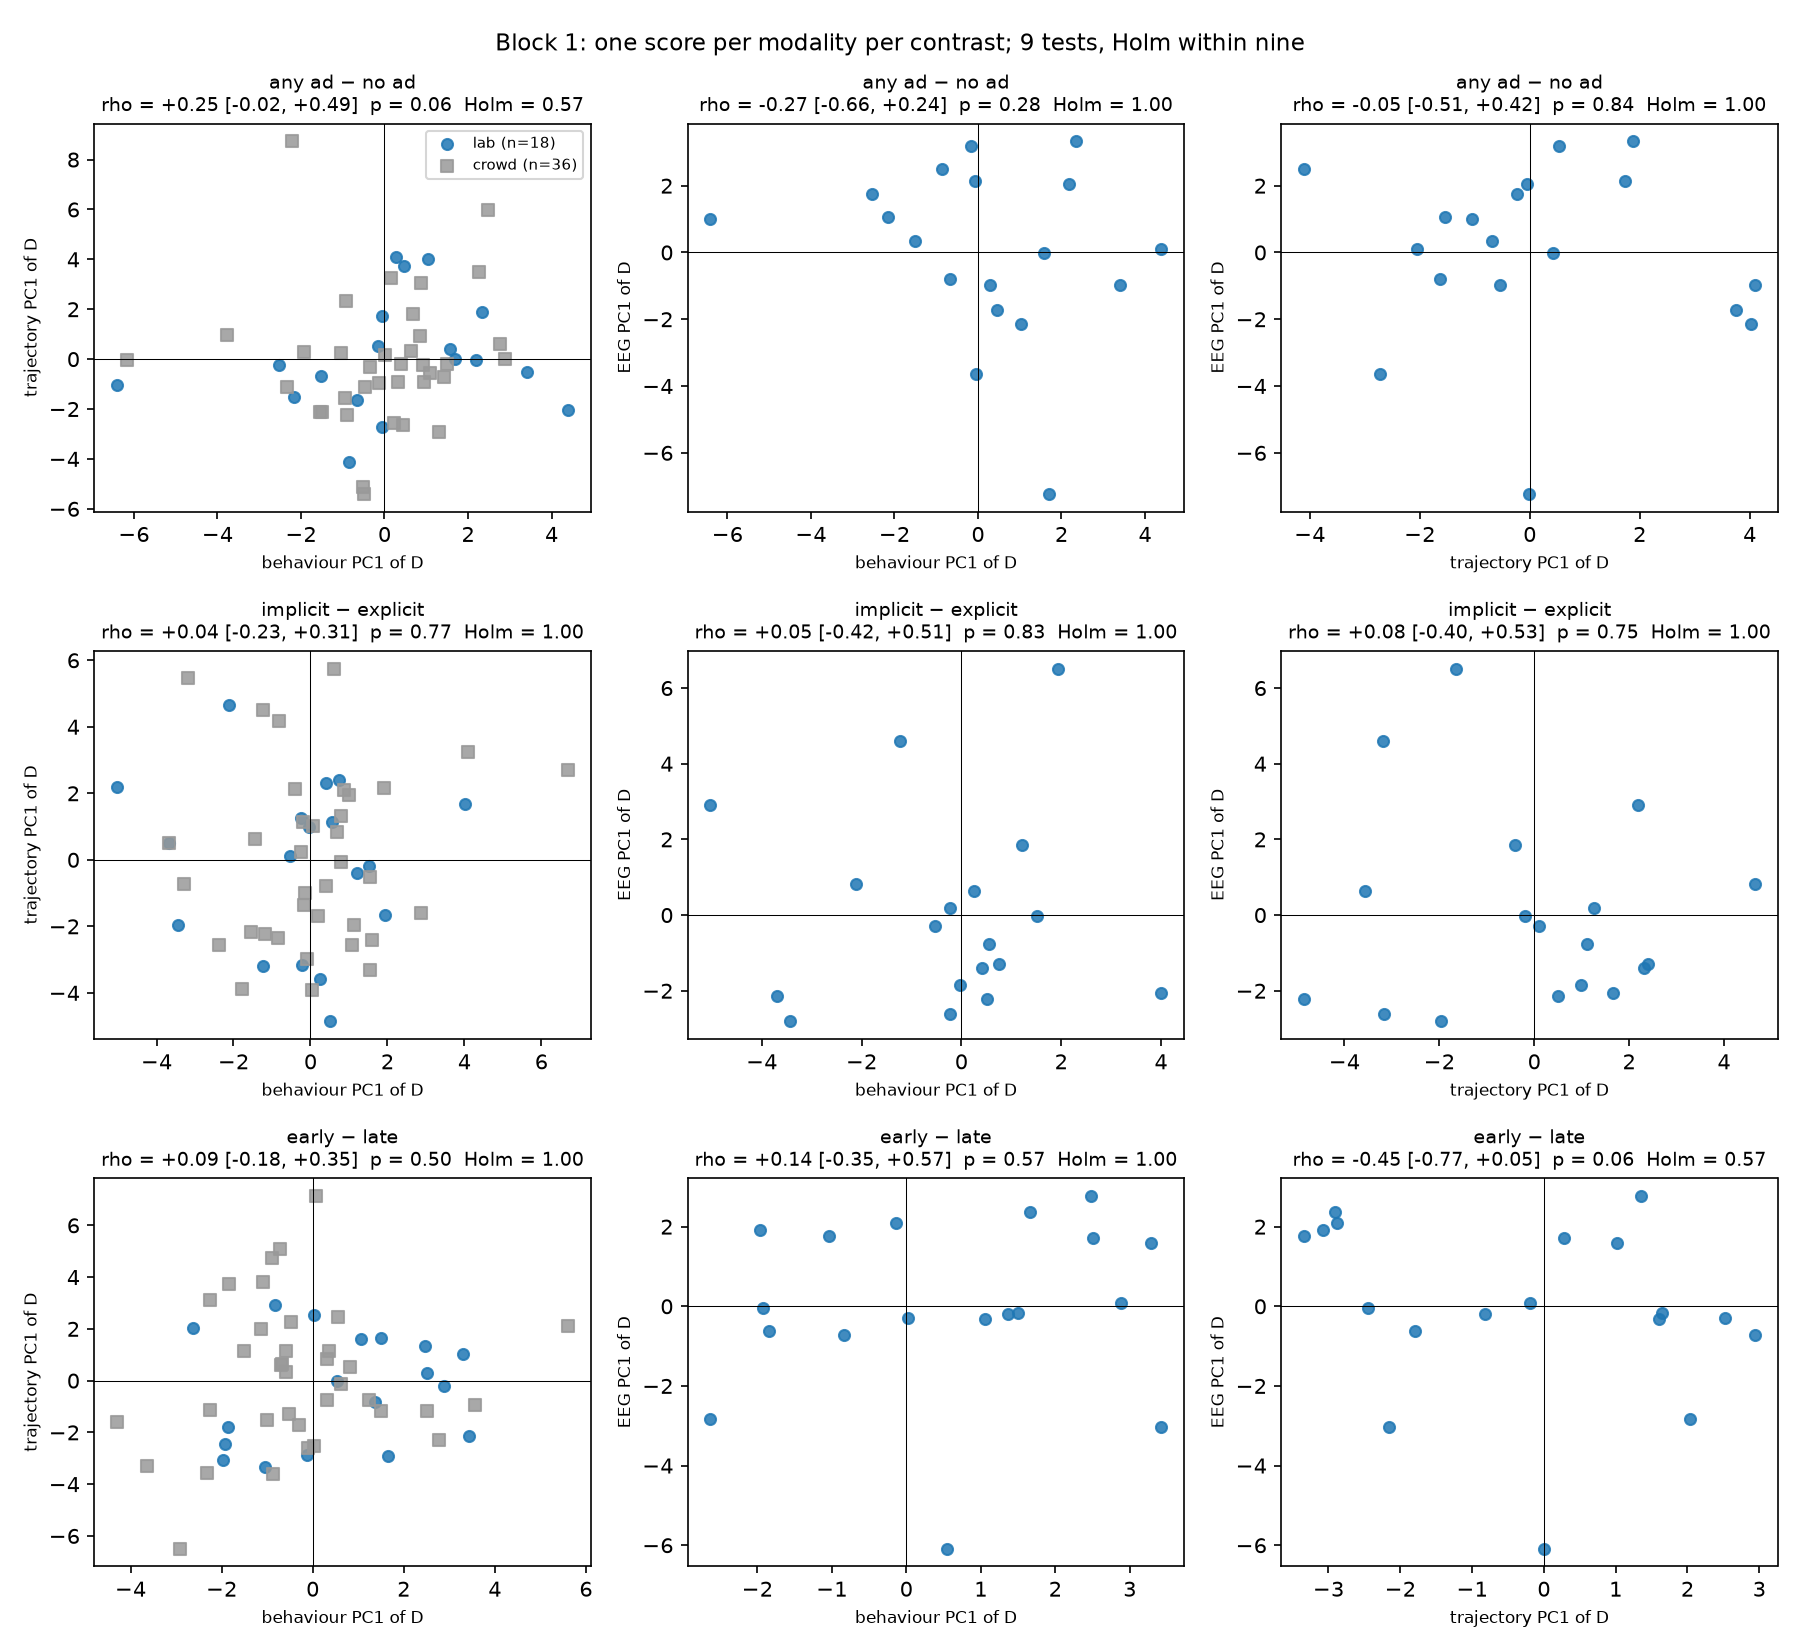

,family,contrast,left,right,arm,n,rho,ci_lo,ci_hi,p_raw,p_holm_family,rho_loo_min,rho_loo_max
7,headline_PC1,any_ad_vs_no_ads,pc1_beh,pc1_traj,all,54,0.254,-0.019,0.492,0.064,0.567,0.223,0.315
11,headline_PC1,any_ad_vs_no_ads,pc1_beh,pc1_eeg,all,18,-0.267,-0.658,0.237,0.284,1.000,-0.451,-0.203
13,headline_PC1,any_ad_vs_no_ads,pc1_traj,pc1_eeg,all,18,-0.053,-0.507,0.425,0.836,1.000,-0.191,0.061
29,headline_PC1,inline_vs_block,pc1_beh,pc1_traj,all,54,0.041,-0.229,0.306,0.768,1.000,0.001,0.089
33,headline_PC1,inline_vs_block,pc1_beh,pc1_eeg,all,18,0.055,-0.423,0.509,0.829,1.000,-0.091,0.203
35,headline_PC1,inline_vs_block,pc1_traj,pc1_eeg,all,18,0.082,-0.401,0.529,0.748,1.000,-0.074,0.228
51,headline_PC1,early_vs_late,pc1_beh,pc1_traj,all,54,0.093,-0.180,0.353,0.503,1.000,0.042,0.133
55,headline_PC1,early_vs_late,pc1_beh,pc1_eeg,all,18,0.143,-0.349,0.574,0.570,1.000,0.044,0.336
57,headline_PC1,early_vs_late,pc1_traj,pc1_eeg,all,18,-0.447,-0.766,0.050,0.063,0.567,-0.569,-0.385


,family,contrast,left,right,arm,n,rho,ci_lo,ci_hi,p_raw,p_holm_family,rho_loo_min,rho_loo_max
15,process_PC1,any_ad_vs_no_ads,pc1_proc,pc1_beh,all,54,0.110,-0.164,0.368,0.429,1.000,0.060,0.159
16,process_PC1,any_ad_vs_no_ads,pc1_proc,pc1_traj,all,54,-0.246,-0.486,0.027,0.072,0.652,-0.283,-0.206
17,process_PC1,any_ad_vs_no_ads,pc1_proc,pc1_eeg,lab,18,0.150,-0.344,0.578,0.553,1.000,0.039,0.248
37,process_PC1,inline_vs_block,pc1_proc,pc1_beh,all,54,-0.111,-0.369,0.162,0.423,1.000,-0.159,-0.071
38,process_PC1,inline_vs_block,pc1_proc,pc1_traj,all,54,-0.063,-0.325,0.209,0.652,1.000,-0.104,-0.019
39,process_PC1,inline_vs_block,pc1_proc,pc1_eeg,lab,18,0.404,-0.098,0.742,0.097,0.774,0.319,0.500
59,process_PC1,early_vs_late,pc1_proc,pc1_beh,all,54,0.194,-0.081,0.441,0.161,1.000,0.165,0.263
60,process_PC1,early_vs_late,pc1_proc,pc1_traj,all,54,-0.153,-0.405,0.121,0.270,1.000,-0.190,-0.118
61,process_PC1,early_vs_late,pc1_proc,pc1_eeg,lab,18,-0.205,-0.617,0.294,0.414,1.000,-0.409,-0.096


,family,contrast,left,right,arm,n,rho,ci_lo,ci_hi,p_raw,p_holm_family,rho_loo_min,rho_loo_max
18,planned_primaries,any_ad_vs_no_ads,pc1_beh,eeg_fz_theta,lab,18,-0.282,-0.667,0.223,0.257,1.0,-0.382,-0.196
19,planned_primaries,any_ad_vs_no_ads,pc1_beh,eeg_posterior_alpha,lab,18,-0.261,-0.654,0.242,0.295,1.0,-0.380,-0.125
20,planned_primaries,any_ad_vs_no_ads,pc1_traj,eeg_fz_theta,lab,18,0.131,-0.360,0.565,0.604,1.0,0.039,0.294
21,planned_primaries,any_ad_vs_no_ads,pc1_traj,eeg_posterior_alpha,lab,18,0.084,-0.400,0.530,0.742,1.0,-0.029,0.287
40,planned_primaries,inline_vs_block,pc1_beh,eeg_fz_theta,lab,18,-0.063,-0.515,0.417,0.804,1.0,-0.189,0.100
41,planned_primaries,inline_vs_block,pc1_beh,eeg_posterior_alpha,lab,18,-0.203,-0.615,0.296,0.418,1.0,-0.299,-0.115
42,planned_primaries,inline_vs_block,pc1_traj,eeg_fz_theta,lab,18,-0.096,-0.540,0.389,0.705,1.0,-0.206,0.074
43,planned_primaries,inline_vs_block,pc1_traj,eeg_posterior_alpha,lab,18,-0.082,-0.529,0.401,0.748,1.0,-0.225,0.091
62,planned_primaries,early_vs_late,pc1_beh,eeg_fz_theta,lab,18,0.018,-0.453,0.481,0.945,1.0,-0.064,0.150
63,planned_primaries,early_vs_late,pc1_beh,eeg_posterior_alpha,lab,18,-0.057,-0.510,0.422,0.823,1.0,-0.162,0.034


,family,contrast,left,right,arm,n,rho,ci_lo,ci_hi,p_raw,p_holm_family,rho_loo_min,rho_loo_max
0,sensitivity_wholewindow_eeg,any_ad_vs_no_ads,pc1_beh,pc1_eeg_wholewindow,lab,18,-0.133,-0.566,0.358,0.598,1.000,-0.275,-0.044
1,sensitivity_wholewindow_eeg,any_ad_vs_no_ads,pc1_traj,pc1_eeg_wholewindow,lab,18,-0.232,-0.635,0.270,0.354,1.000,-0.328,-0.088
2,sensitivity_wholewindow_eeg,any_ad_vs_no_ads,pc1_proc,pc1_eeg_wholewindow,lab,18,0.191,-0.307,0.607,0.448,1.000,0.049,0.311
3,sensitivity_wholewindow_eeg,any_ad_vs_no_ads,pc1_beh,eeg_fz_theta_wholewindow,lab,18,-0.222,-0.628,0.279,0.376,1.000,-0.326,-0.076
4,sensitivity_wholewindow_eeg,any_ad_vs_no_ads,pc1_beh,eeg_posterior_alpha_wholewindow,lab,18,-0.073,-0.523,0.408,0.773,1.000,-0.169,0.096
5,sensitivity_wholewindow_eeg,any_ad_vs_no_ads,pc1_traj,eeg_fz_theta_wholewindow,lab,18,0.269,-0.235,0.659,0.280,1.000,0.174,0.397
6,sensitivity_wholewindow_eeg,any_ad_vs_no_ads,pc1_traj,eeg_posterior_alpha_wholewindow,lab,18,0.158,-0.336,0.584,0.531,1.000,0.066,0.375
8,sensitivity_zmean,any_ad_vs_no_ads,zmean_beh,zmean_traj,all,54,0.265,-0.007,0.501,0.052,0.472,0.235,0.330
9,sensitivity_lab_only,any_ad_vs_no_ads,pc1_beh,pc1_traj,lab,18,0.294,-0.211,0.675,0.236,0.708,0.218,0.483
10,sensitivity_partial_arm,any_ad_vs_no_ads,pc1_beh,pc1_traj,all|arm,54,0.251,NaN,NaN,0.070,0.209,NaN,NaN


Whole-window EEG (all ~95 tiles) in place of \(k=37\): 21 tests, min raw \(p=.03\), 0 Holm. Its PC1 agrees with the \(k=37\) PC1 only for any-ad (.85), not for format or timing (−.38, −.55): PC1 of sixteen \(D\)'s from 18 people is not a stable axis when the \(D\)'s are small.

,contrast,modality,n,k_vars,pc1_var_explained,pc1_zmean_spearman,pc1_loo_min_score_spearman,pc1_loo_min_loading_cosine,pc1_loo_n_fits,spearman_with_k37_pc1
0,any_ad_vs_no_ads,beh,54,8,0.514,0.982,0.997,0.991,54,NaN
1,any_ad_vs_no_ads,traj,54,10,0.651,0.984,0.999,0.998,54,NaN
2,any_ad_vs_no_ads,eeg,18,16,0.431,0.990,0.824,0.836,18,NaN
3,any_ad_vs_no_ads,proc,54,3,0.703,0.999,0.998,0.993,54,NaN
4,any_ad_vs_no_ads,eeg_wholewindow,18,16,0.421,NaN,0.988,0.984,18,0.845
5,inline_vs_block,beh,54,8,0.523,0.984,0.998,0.998,54,NaN
6,inline_vs_block,traj,54,10,0.655,0.991,0.999,0.999,54,NaN
7,inline_vs_block,eeg,18,16,0.415,0.967,0.990,0.954,18,NaN
8,inline_vs_block,proc,54,3,0.908,1.000,0.999,1.000,54,NaN
9,inline_vs_block,eeg_wholewindow,18,16,0.369,NaN,0.605,0.683,18,-0.377


Leave-one-person-out refits (`pc1_loo_*`): behaviour, trajectory and process PC1 reproduce the full fit at \(\ge .99\) whichever person is dropped. The EEG PC1 does not: minimum score agreement .82 / .99 / .83 and minimum loading cosine .84 / .95 / .67 for any-ad / format / timing at \(k=37\), and .61 / .68 for the whole-window format axis. The EEG 'tilt' score at the timing contrast hinges on single people.

In [5]:
show("headline/pc1_loadings.png", 1200)
show("headline/headline_scatter.png", 1000)
H = pd.read_csv(OUT / "headline/headline_tests.csv")
cols = ["family", "contrast", "left", "right", "arm", "n", "rho", "ci_lo", "ci_hi", "p_raw", "p_holm_family", "rho_loo_min", "rho_loo_max"]
display(H[H.family == "headline_PC1"][cols].round(3))
display(H[H.family == "process_PC1"][cols].round(3))
display(H[H.family == "planned_primaries"][cols].round(3))
display(H[H.family.str.startswith("sensitivity")][cols].round(3))
display(Markdown(r"Whole-window EEG (all ~95 tiles) in place of \(k=37\): 21 tests, min raw \(p=.03\), 0 Holm. Its PC1 agrees with the \(k=37\) PC1 only for any-ad (.85), not for format or timing (−.38, −.55): PC1 of sixteen \(D\)'s from 18 people is not a stable axis when the \(D\)'s are small."))
display(pd.read_csv(OUT / "headline/pc1_variance.csv").round(3))
display(Markdown(r"Leave-one-person-out refits (`pc1_loo_*`): behaviour, trajectory and process PC1 reproduce the full fit at \(\ge .99\) whichever person is dropped. The EEG PC1 does not: minimum score agreement .82 / .99 / .83 and minimum loading cosine .84 / .95 / .67 for any-ad / format / timing at \(k=37\), and .61 / .68 for the whole-window format axis. The EEG 'tilt' score at the timing contrast hinges on single people."))

Nothing survives. The two closest cells are behaviour × trajectory any-ad (\(\rho=.25\), \(n=54\), \(p=.06\); people whose evaluation worsened with ads moved genre a little more) and trajectory × EEG early−late (\(\rho=-.45\), \(n=18\), \(p=.06\)). Process PC1 × EEG PC1 at the format contrast is \(\rho=.40\) (\(p=.10\)), the same direction as the raw process × engagement cluster in the old map.

## Block 2 — the a-priori cells with their intervals

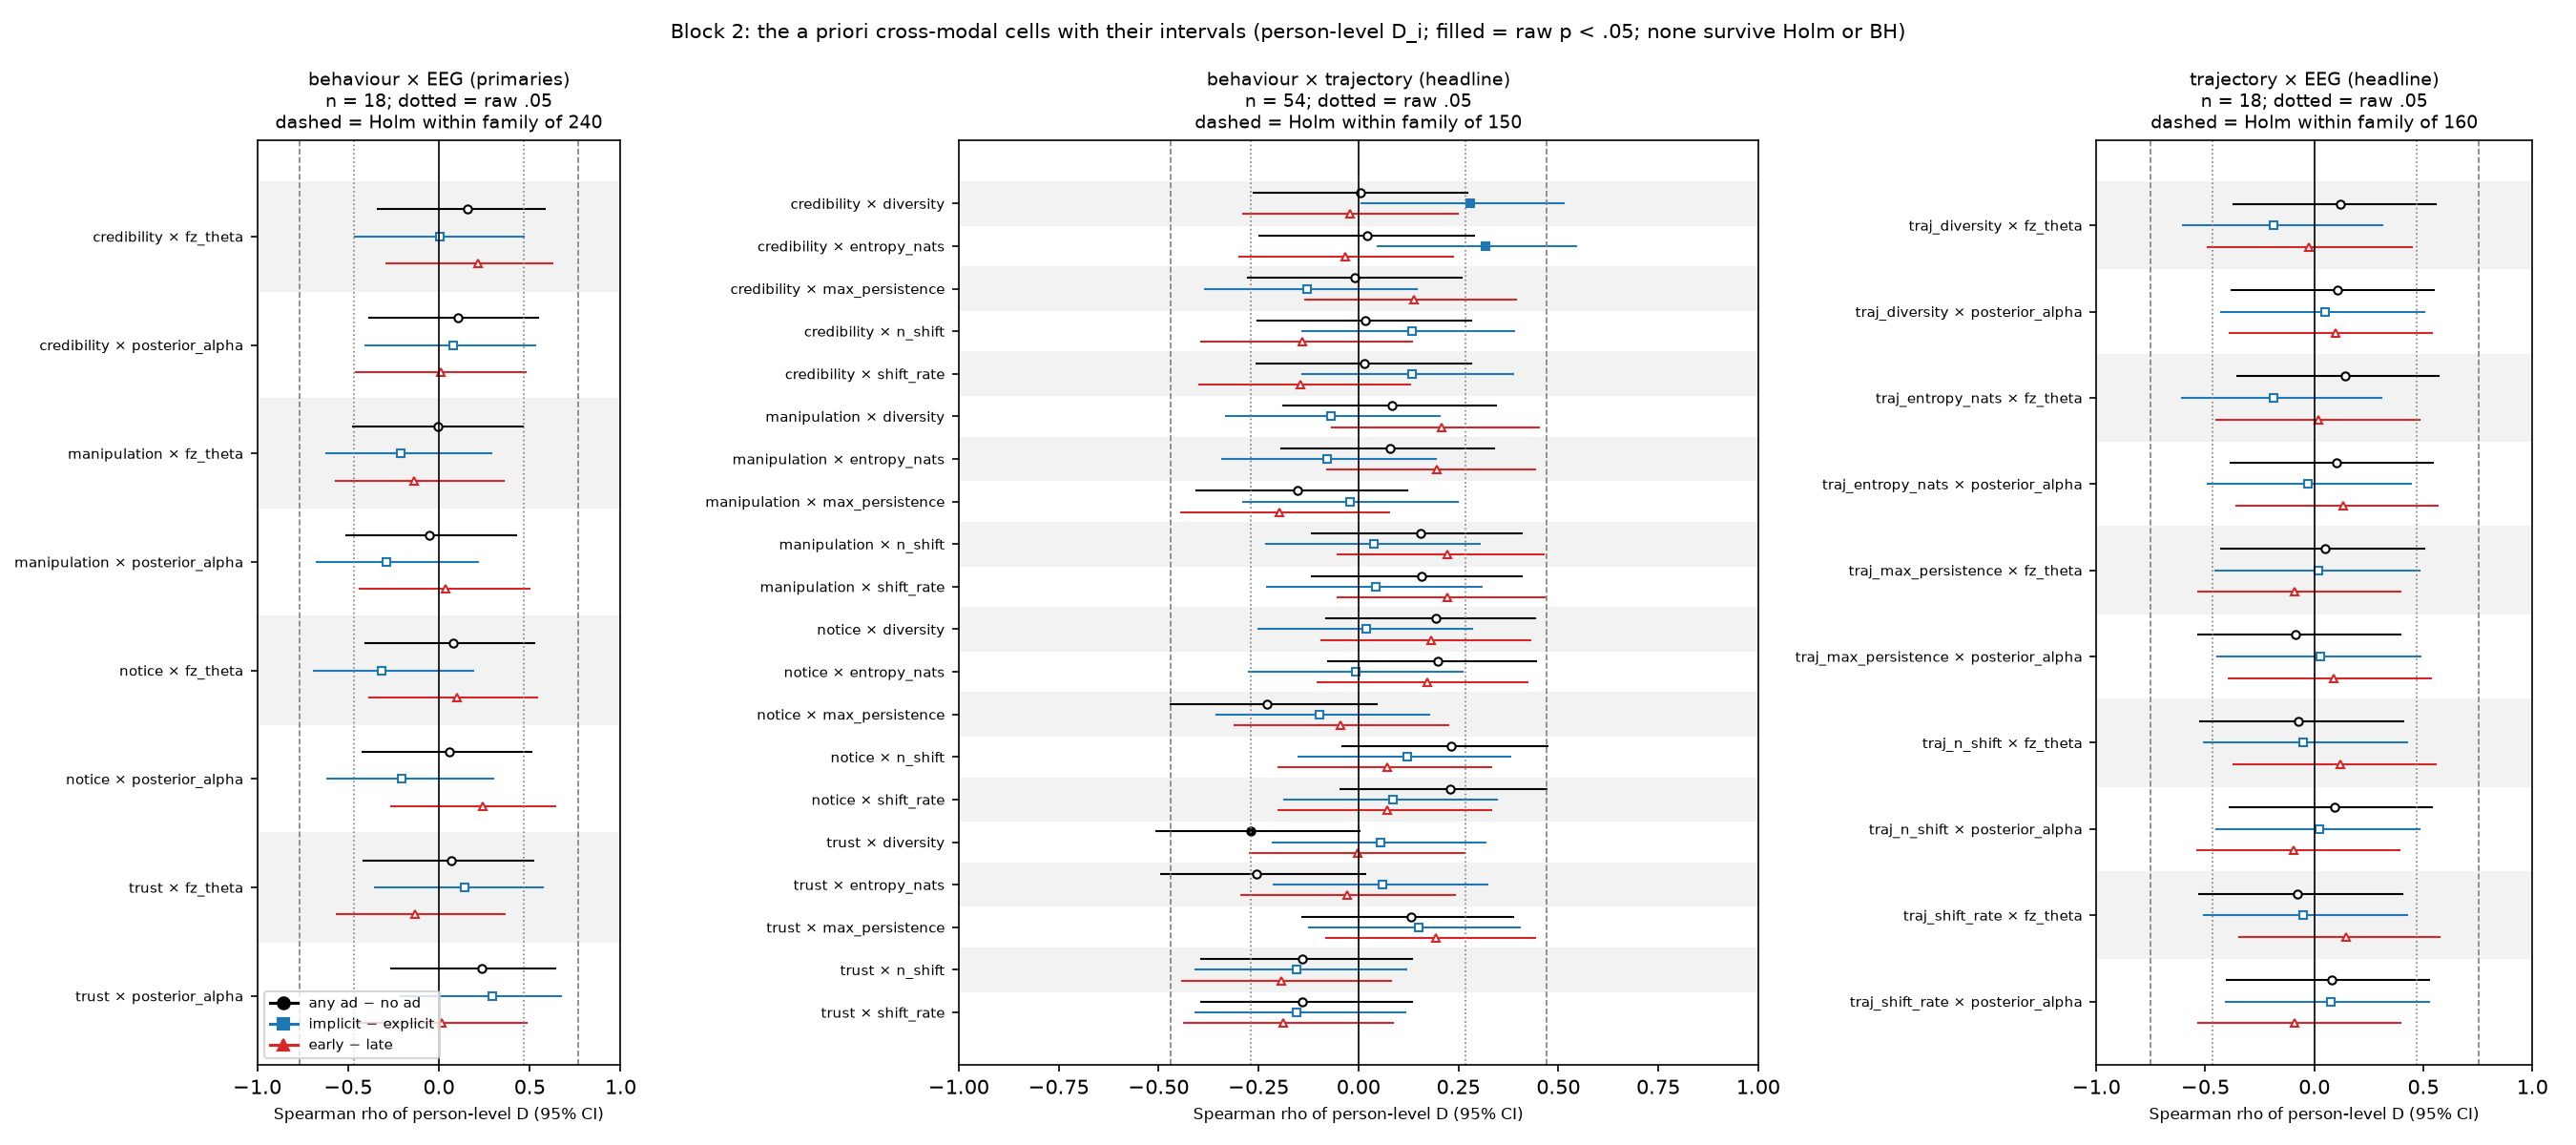

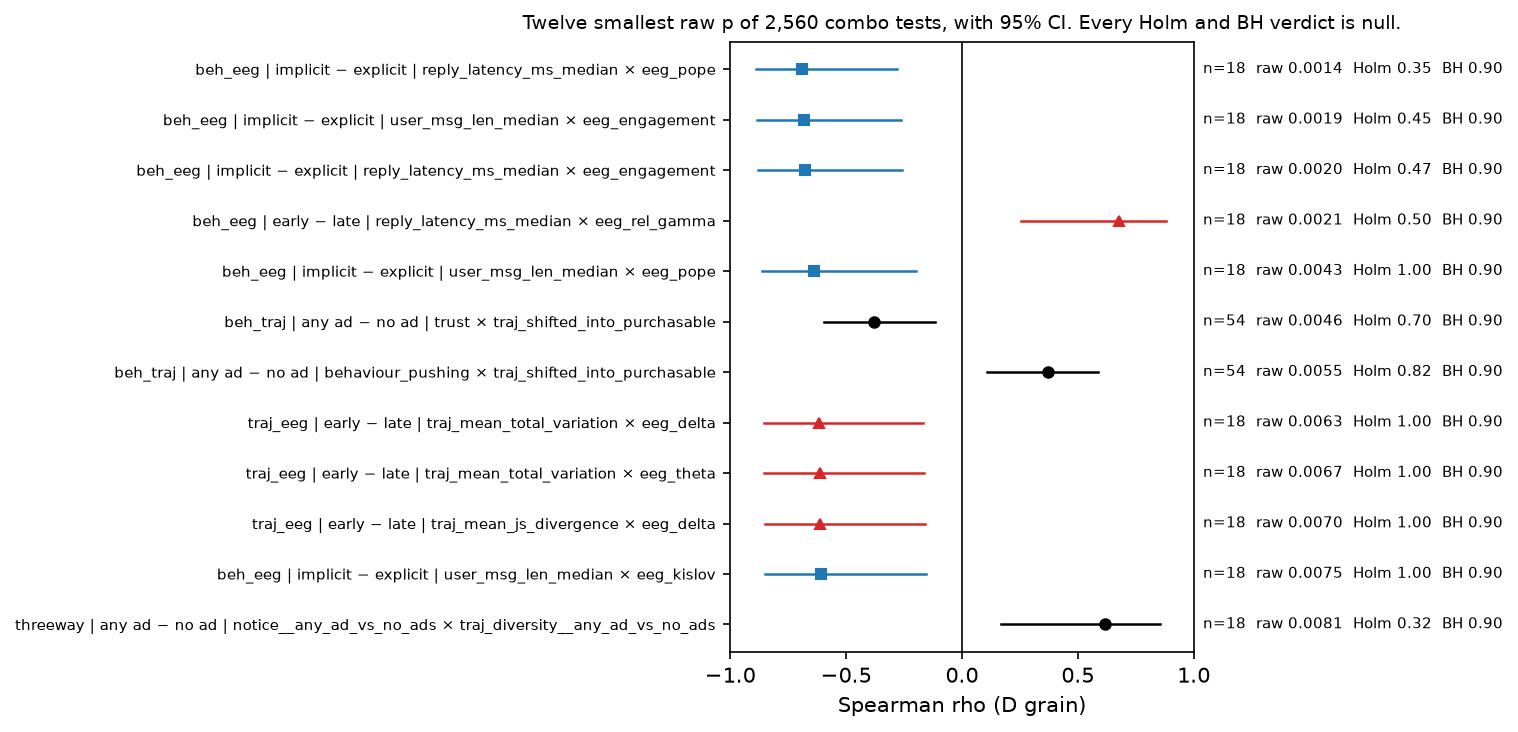

,left,right,n,effect,p_raw,p_holm_family,p_bh_global
0,reply_latency_ms_median,eeg_pope,18.0,-0.692,0.001,0.347,0.896
1,user_msg_len_median,eeg_engagement,18.0,-0.680,0.002,0.454,0.896
2,reply_latency_ms_median,eeg_engagement,18.0,-0.678,0.002,0.472,0.896
3,user_msg_len_median,eeg_pope,18.0,-0.639,0.004,1.000,0.896
4,user_msg_len_median,eeg_kislov,18.0,-0.608,0.007,1.000,0.896
5,duration_sec,eeg_engagement,18.0,-0.564,0.015,1.000,0.896
6,reply_latency_ms_median,eeg_kislov,18.0,-0.534,0.023,1.000,0.980
7,duration_sec,eeg_pope,18.0,-0.515,0.029,1.000,0.996
8,user_msg_len_median,eeg_gamma,18.0,-0.494,0.037,1.000,0.996
9,user_msg_len_median,eeg_beta,18.0,-0.453,0.059,1.000,0.996


In [6]:
show("forest/forest_headline.png", 1300)
show("forest/forest_top12.png", 1100)
display(pd.read_csv(OUT / "forest/cluster_process_x_engagement_format.csv")[["left", "right", "n", "effect", "p_raw", "p_holm_family", "p_bh_global"]].round(3))

Every a-priori interval crosses zero. The twelve smallest raw \(p\) of the 2,560 have Holm \(\ge .32\) and BH \(.90\). The one coherent raw cluster — all 21 process × fast-band cells at the format contrast are negative (\(\rho\) −0.15 to −0.69) — is not 21 independent replications (the variables within it are correlated) and is exploratory.

## Block 3 — mixed models: EEG state → outcome, and EEG × timing/format

Laboratory 90 rows (Model A, adjusted for condition and order), 72 ad rows (B0 main effect; B two interactions). EEG within-person centred; person random intercept. Freedman–Lane max-\(|t|\) permutation per family.

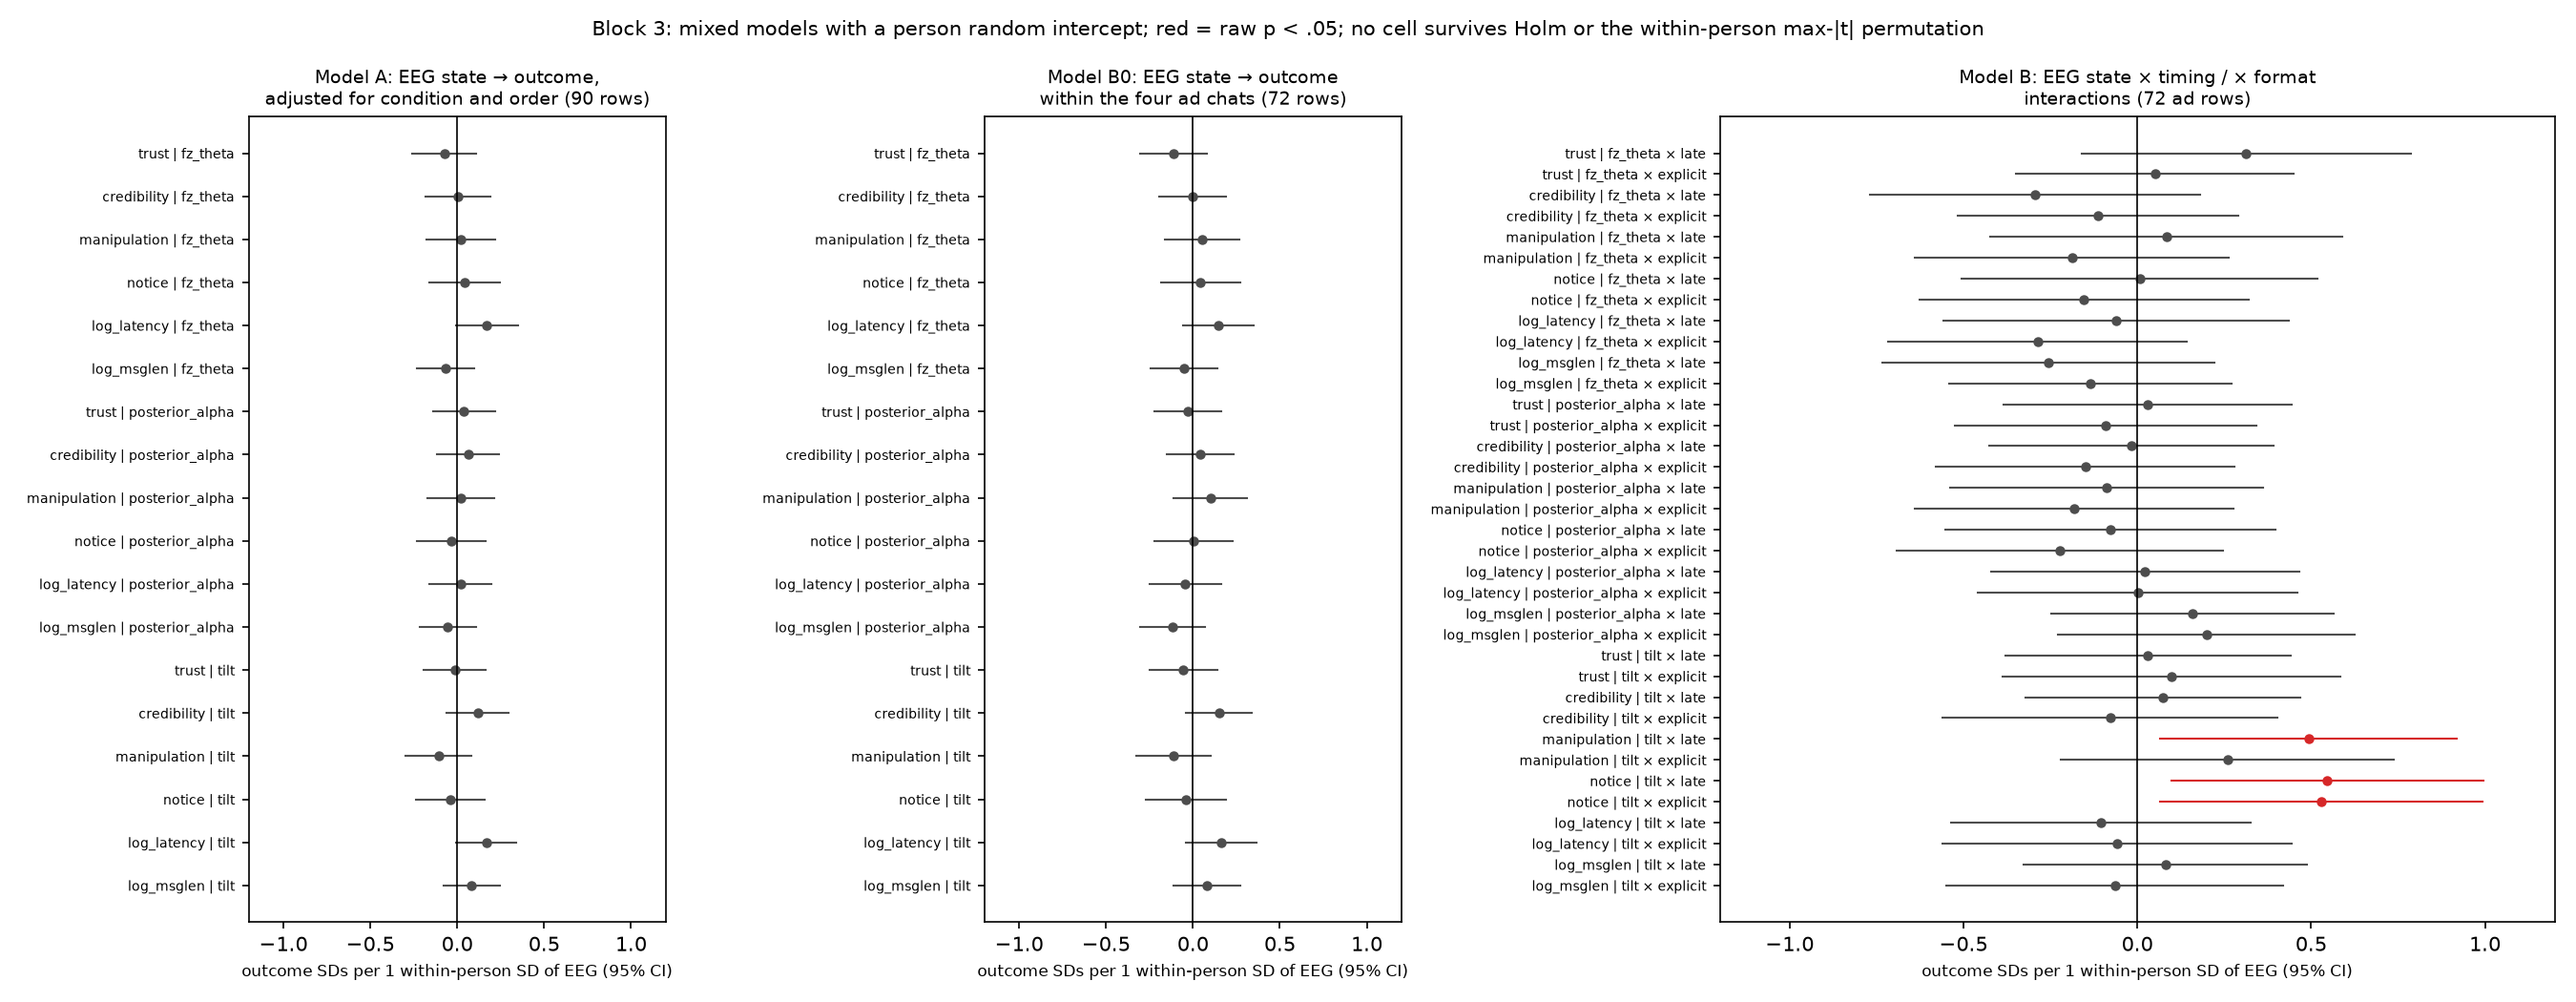

,observed_max_abs_t,p_perm_family,null_95pct_max_abs_t,n_perm,method
A,1.88844,0.689655,3.109096,2000,"Freedman-Lane, residuals permuted within person"
B0,1.776905,0.736632,3.033604,2000,"Freedman-Lane, residuals permuted within person"
B,1.877849,0.893553,3.341574,2000,"Freedman-Lane, residuals permuted within person"


,family,outcome,eeg,term,beta,se,p_raw,p_holm_family
0,B_moderation,notice,eeg_tilt,late:eeg_tilt_wc,1.2145,0.5091,0.0171,0.6140
1,B_moderation,manipulation,eeg_tilt,late:eeg_tilt_wc,1.0520,0.4655,0.0238,0.8332
2,B_moderation,notice,eeg_tilt,explicit:eeg_tilt_wc,1.1755,0.5271,0.0257,0.8750
3,A_state_association,log_latency,eeg_tilt,eeg_tilt_wc,0.0913,0.0483,0.0590,1.0000
4,A_state_association,log_latency,eeg_fz_theta,eeg_fz_theta_wc,0.0929,0.0497,0.0614,1.0000
5,B0_main_within_ads,log_latency,eeg_tilt,eeg_tilt_wc,0.0876,0.0562,0.1188,1.0000
6,B0_main_within_ads,credibility,eeg_tilt,eeg_tilt_wc,0.1952,0.1260,0.1214,1.0000
7,B0_main_within_ads,log_latency,eeg_fz_theta,eeg_fz_theta_wc,0.0786,0.0560,0.1605,1.0000


In [7]:
show("lmm/lmm_forest.png", 1300)
M = js("lmm/summary.json")
display(pd.DataFrame(M["permutation_maxT"]).T.round(3))
display(pd.DataFrame(M["top"]).round(4))

## Block 4 — turn grain: genre movement × process, and the post-ad turn

1,080 user turns, person + conversation effects, `task_genre` covariate (task assignment is randomised, not counterbalanced). Early ads appear in reply 2, so turns 3–4 are the only post-ad user turns; late ads have none.

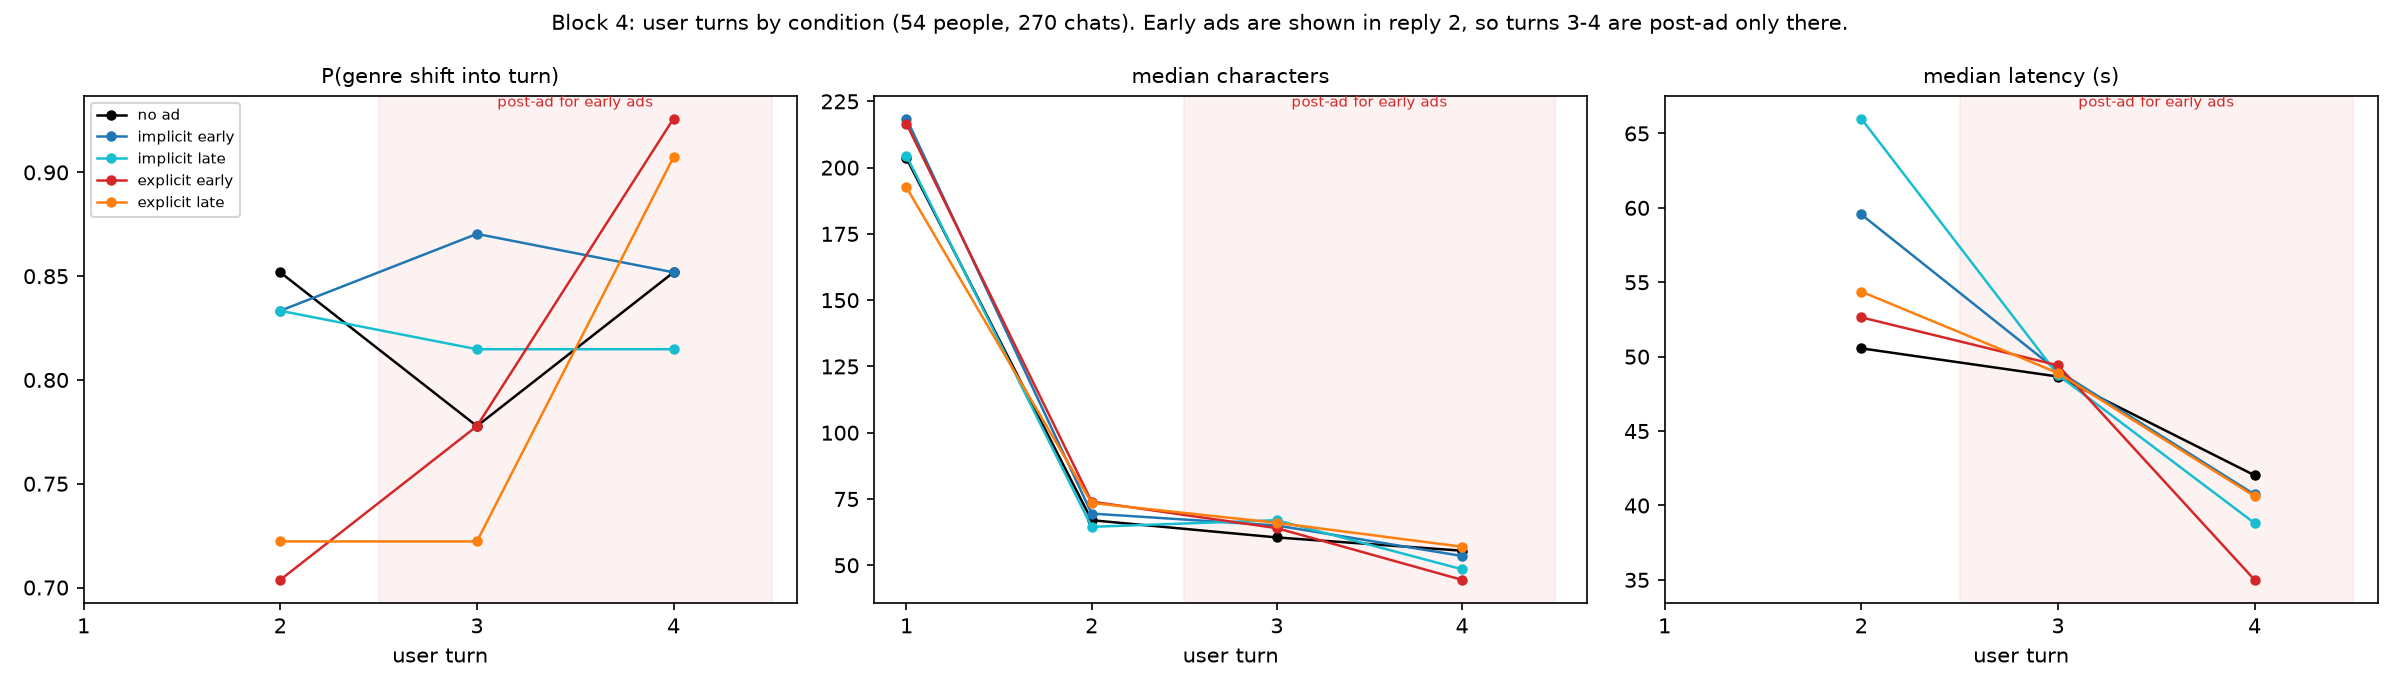

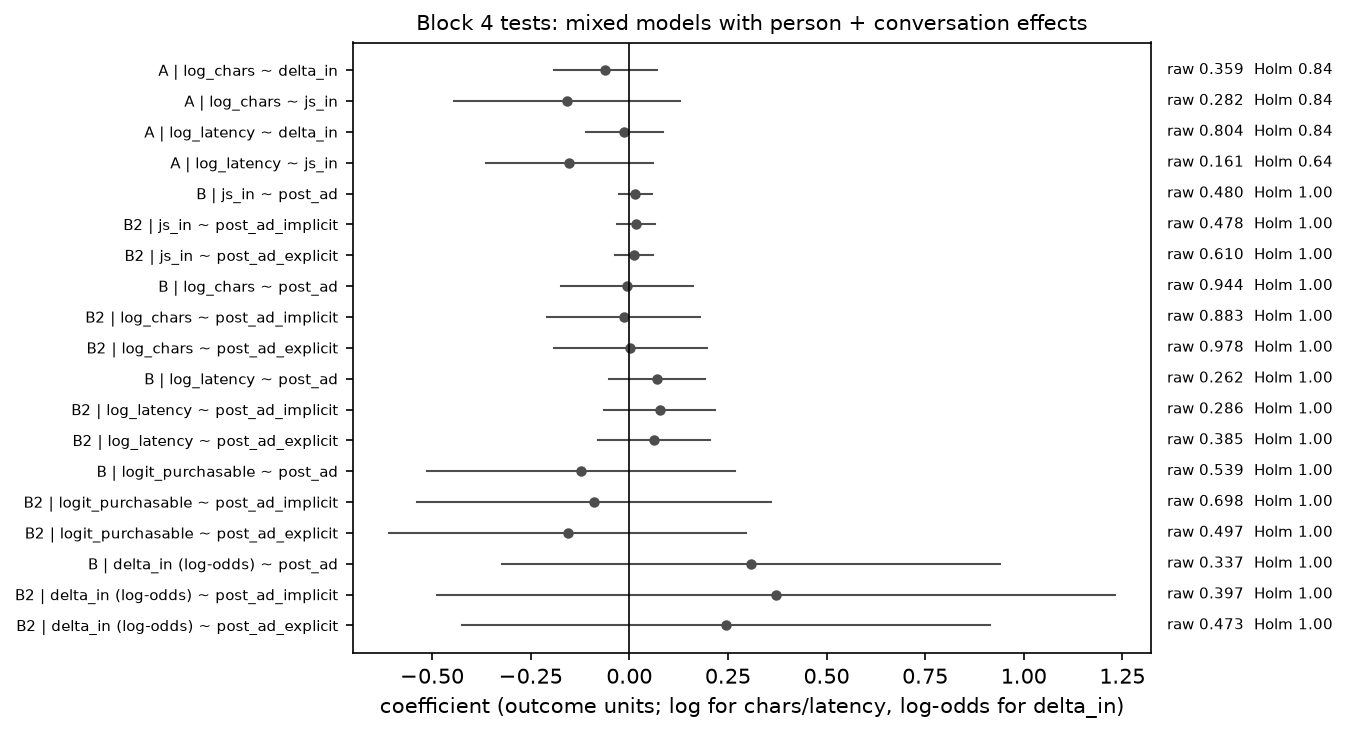

,condition,turn,n,shift_rate,js_in,chars_median,latency_median,p_purchasable_mean
0,block_early,1,54,NaN,NaN,216.5,NaN,0.096
1,block_early,2,54,0.704,0.304,74.0,52.644,0.079
2,block_early,3,54,0.778,0.300,64.0,49.419,0.067
3,block_early,4,54,0.926,0.342,44.5,35.002,0.064
4,block_late,1,54,NaN,NaN,192.5,NaN,0.068
5,block_late,2,54,0.722,0.291,73.5,54.372,0.104
6,block_late,3,54,0.722,0.264,66.0,48.904,0.089
7,block_late,4,54,0.907,0.360,57.0,40.624,0.059
8,inline_early,1,54,NaN,NaN,218.5,NaN,0.096
9,inline_early,2,54,0.833,0.316,69.5,59.559,0.075


In [8]:
show("turns/turn_profiles.png", 1200)
show("turns/turn_forest.png", 1000)
display(pd.read_csv(OUT / "turns/turn_descriptives.csv").round(3))

A turn that changes genre is not measurably shorter, longer or slower. The post-ad turn is between −16 % and +18 % in length and between −5 % and +21 % in latency of a turn at the same position with no ad on screen (95 % CI); its shift log-odds are +0.31 [−0.32, 0.94], and its probability mass on purchasable products does not move.

## Block 5 — event grain: the onset-locked EEG response to *this* ad → what happened next

72 primary-eligible ads (Dataset B post − pre), person random intercept, EEG within-person centred. Targets: cued recall (memory, trust shift), the chat's notice / manipulation / trust, Definition 6 shift and divergence (36 early ads), the next user turn's length and latency (36).

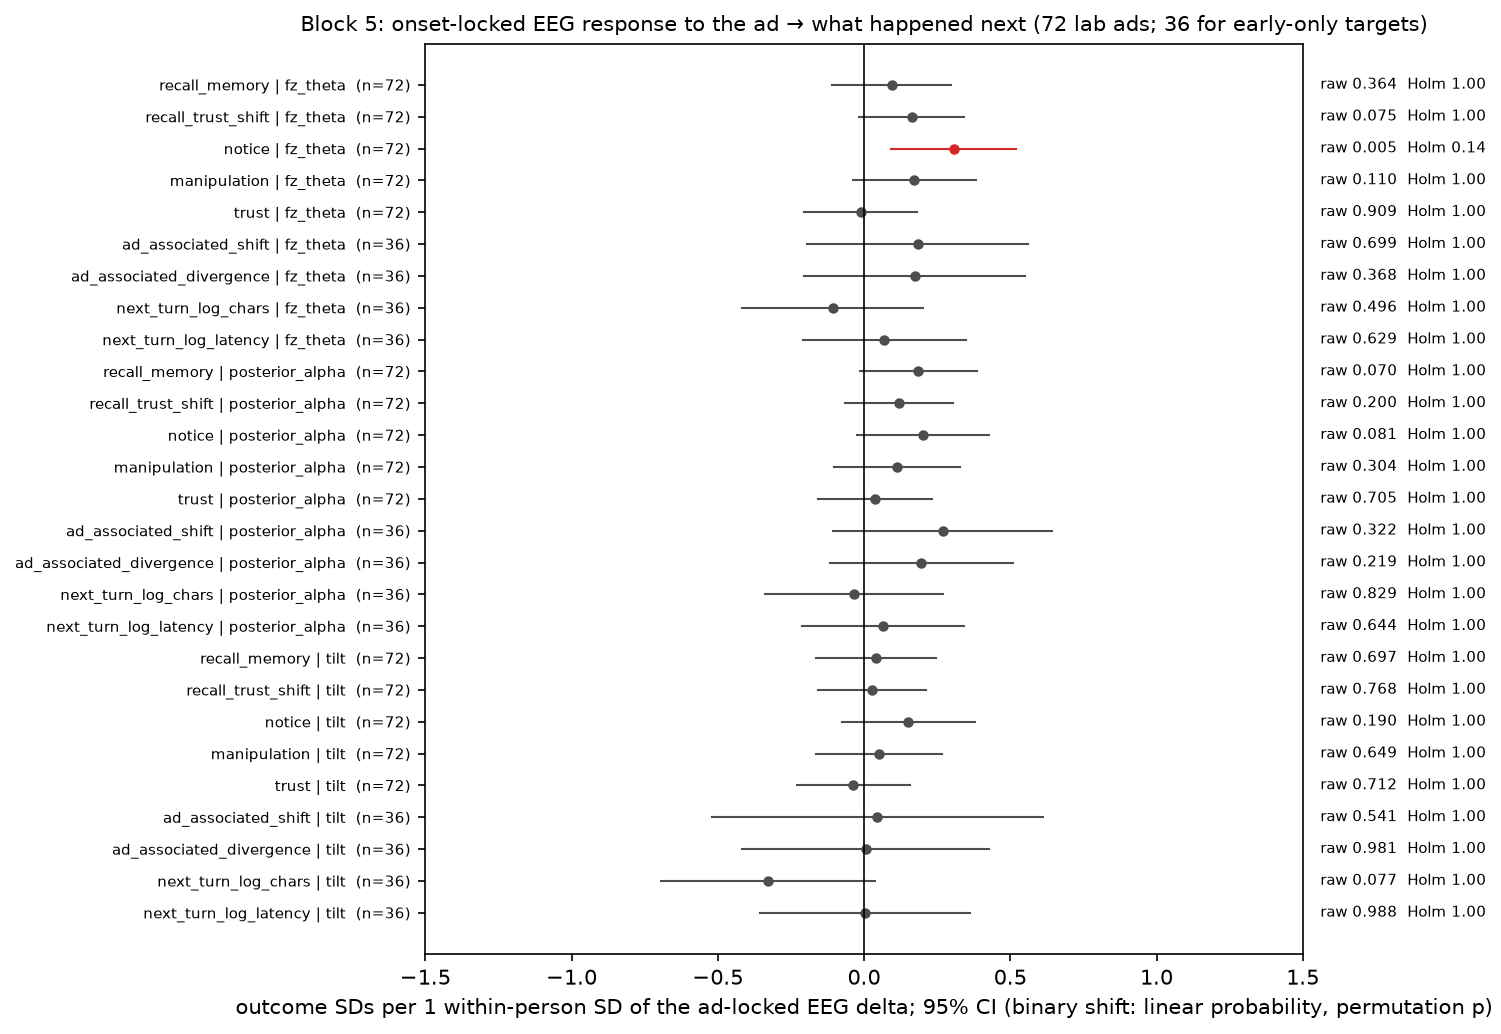

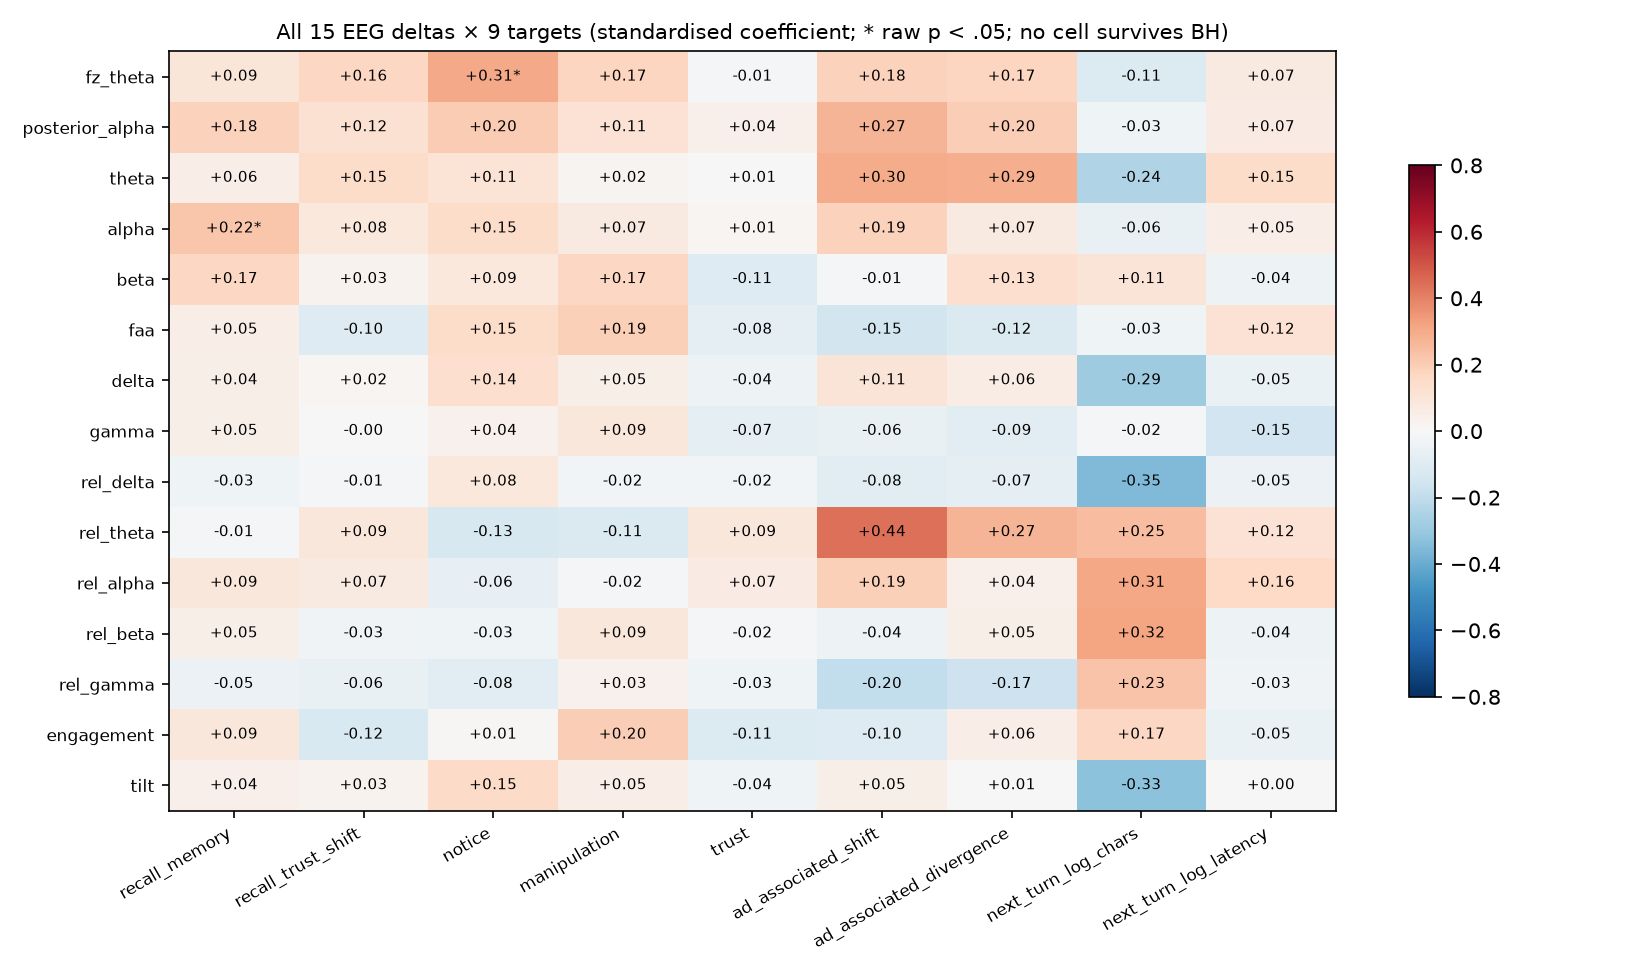

,headline,all
observed_max_abs_t,2.786963,3.093355
p_perm_family,0.233883,0.355322
null_95pct_max_abs_t,3.348321,3.897696
n_perm,2000,2000
method,"Freedman-Lane, residuals permuted within person","Freedman-Lane, residuals permuted within person"


,family,target,eeg,n_obs,beta,se,p_raw,p_perm_cell,p_holm_family,p_bh_global
0,events_headline,notice,eeg_fz_theta,72,0.6809,0.2442,0.0053,0.0195,0.1431,0.7156
1,events_all_exploratory,recall_memory,eeg_alpha,72,0.4857,0.2104,0.0210,0.0255,1.0000,0.9566
2,events_all_exploratory,next_turn_log_chars,eeg_rel_delta,36,-0.3018,0.1550,0.0516,0.1379,1.0000,0.9566
3,events_all_exploratory,manipulation,eeg_engagement,72,0.4194,0.2208,0.0574,0.2734,1.0000,0.9566
4,events_headline,recall_memory,eeg_posterior_alpha,72,0.3998,0.2210,0.0704,0.0975,1.0000,0.9566
5,events_all_exploratory,manipulation,eeg_faa,72,0.4006,0.2236,0.0732,0.0355,1.0000,0.9566
6,events_all_exploratory,next_turn_log_chars,eeg_rel_beta,36,0.2737,0.1538,0.0752,0.1104,1.0000,0.9566
7,events_headline,recall_trust_shift,eeg_fz_theta,72,0.3385,0.1904,0.0754,0.0720,1.0000,0.9566


n_cells               135.00000
n_raw_wald_lt_05        2.00000
n_perm_cell_lt_05       4.00000
spearman_wald_perm      0.82622
dtype: float64

,eeg,beta,se,p_raw,gee_beta_logodds,gee_p_asymptotic,n_events,n_nonevents
5,eeg_fz_theta,0.051,0.054,0.699,0.907,0.251,33.0,3.0
14,eeg_posterior_alpha,0.075,0.054,0.322,0.858,0.298,33.0,3.0
23,eeg_theta,0.084,0.079,0.157,-0.043,0.935,33.0,3.0
32,eeg_alpha,0.052,0.059,0.300,0.728,0.483,33.0,3.0
41,eeg_beta,-0.004,0.076,0.931,4.633,0.002,33.0,3.0
50,eeg_faa,-0.041,0.056,0.111,-0.779,0.033,33.0,3.0
59,eeg_delta,0.029,0.089,0.765,-0.430,0.637,33.0,3.0
68,eeg_gamma,-0.017,0.080,0.799,1.107,0.000,33.0,3.0
77,eeg_rel_delta,-0.023,0.081,0.423,-1.287,0.080,33.0,3.0
86,eeg_rel_theta,0.124,0.078,0.167,1.417,0.055,33.0,3.0


In [9]:
show("events/event_forest.png", 1000)
show("events/event_heat.png", 1000)
E = js("events/summary.json")
display(pd.DataFrame({"headline": E["permutation_headline"], "all": E["permutation_all_exploratory"]}).round(3))
display(pd.DataFrame(E["top"]).round(4))
display(pd.Series(E["wald_vs_permutation"]))
T = pd.read_csv(OUT / "events/event_tests.csv")
display(T[T.target == "ad_associated_shift"][["eeg", "beta", "se", "p_raw", "gee_beta_logodds", "gee_p_asymptotic", "n_events", "n_nonevents"]].round(3))

The best a-priori cell is ad-locked Fz \(\theta\) → notice (0.68 Likert per within-person SD, raw .005, Holm .14, sign stable under leave-one-person-out); the family-wise permutation \(p\) is .23. **Methods warning kept on purpose:** the binary target is 33 shifts / 3 non-shifts, so only three people are informative. A GEE binomial fit returned \(\gamma\) \(p=.0003\) and \(\beta\) \(p=.002\) there; the person-fixed-effects Freedman–Lane permutation gives .80 and .93. The GEE numbers are in the table as a record of why they were not used.

## Block 6 — do the modalities order the conditions alike? (descriptive)

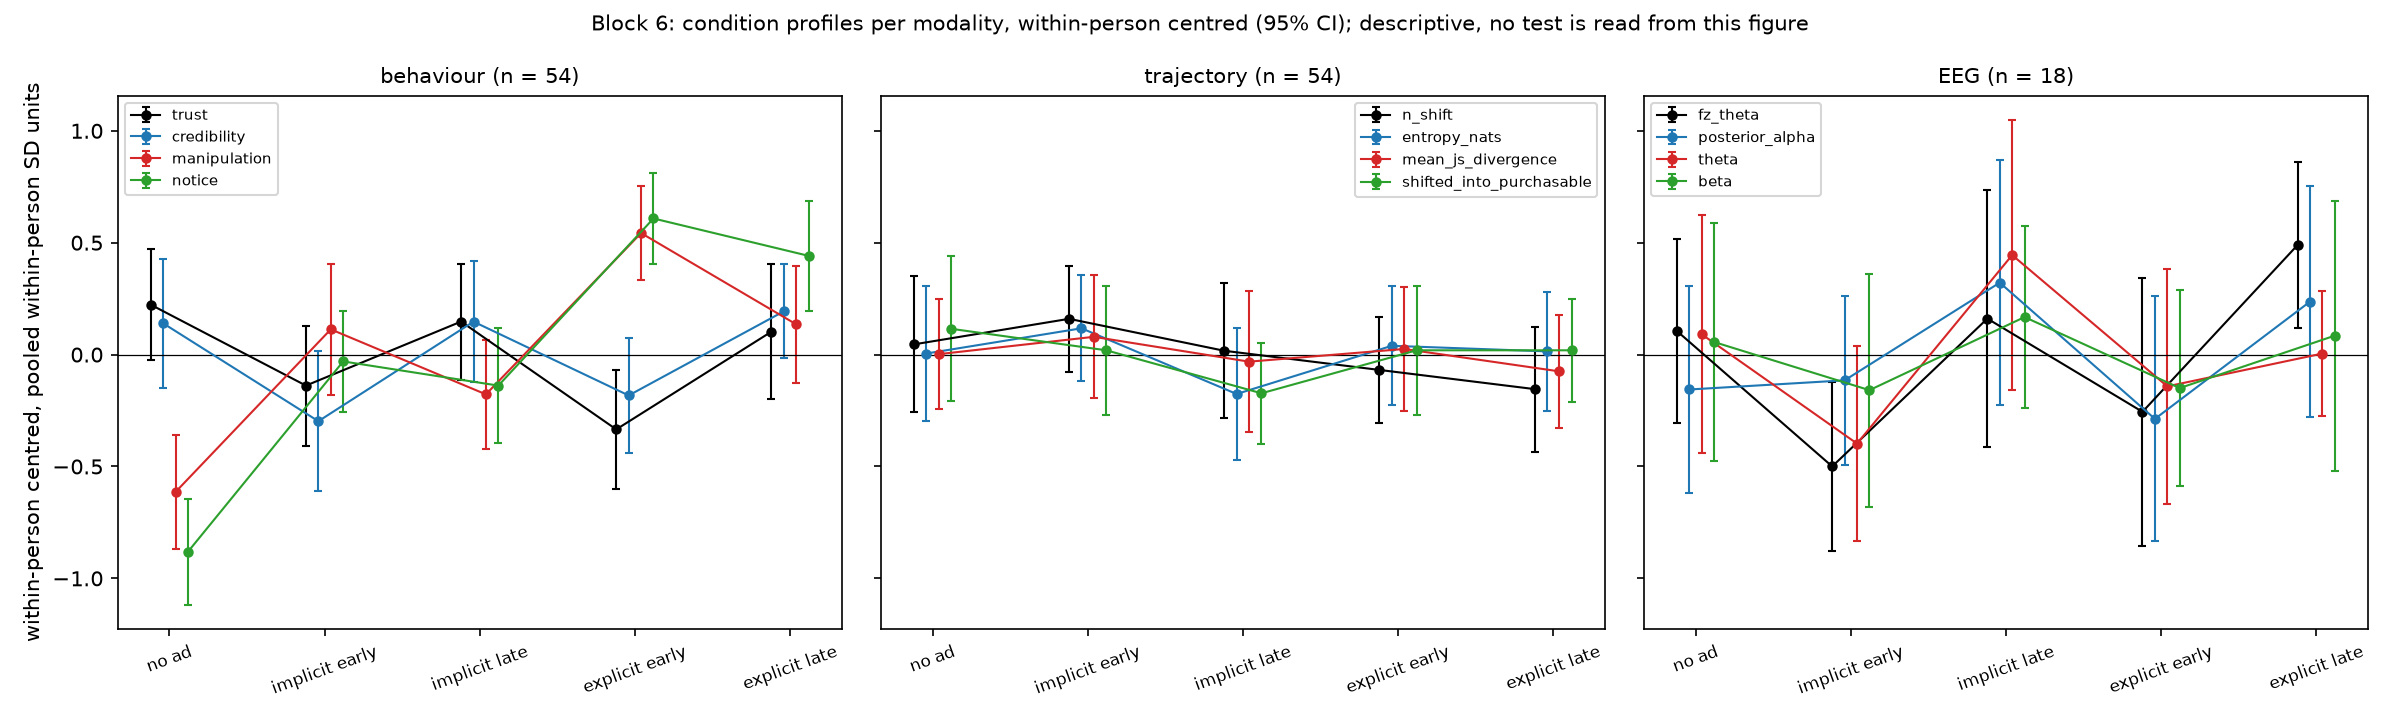

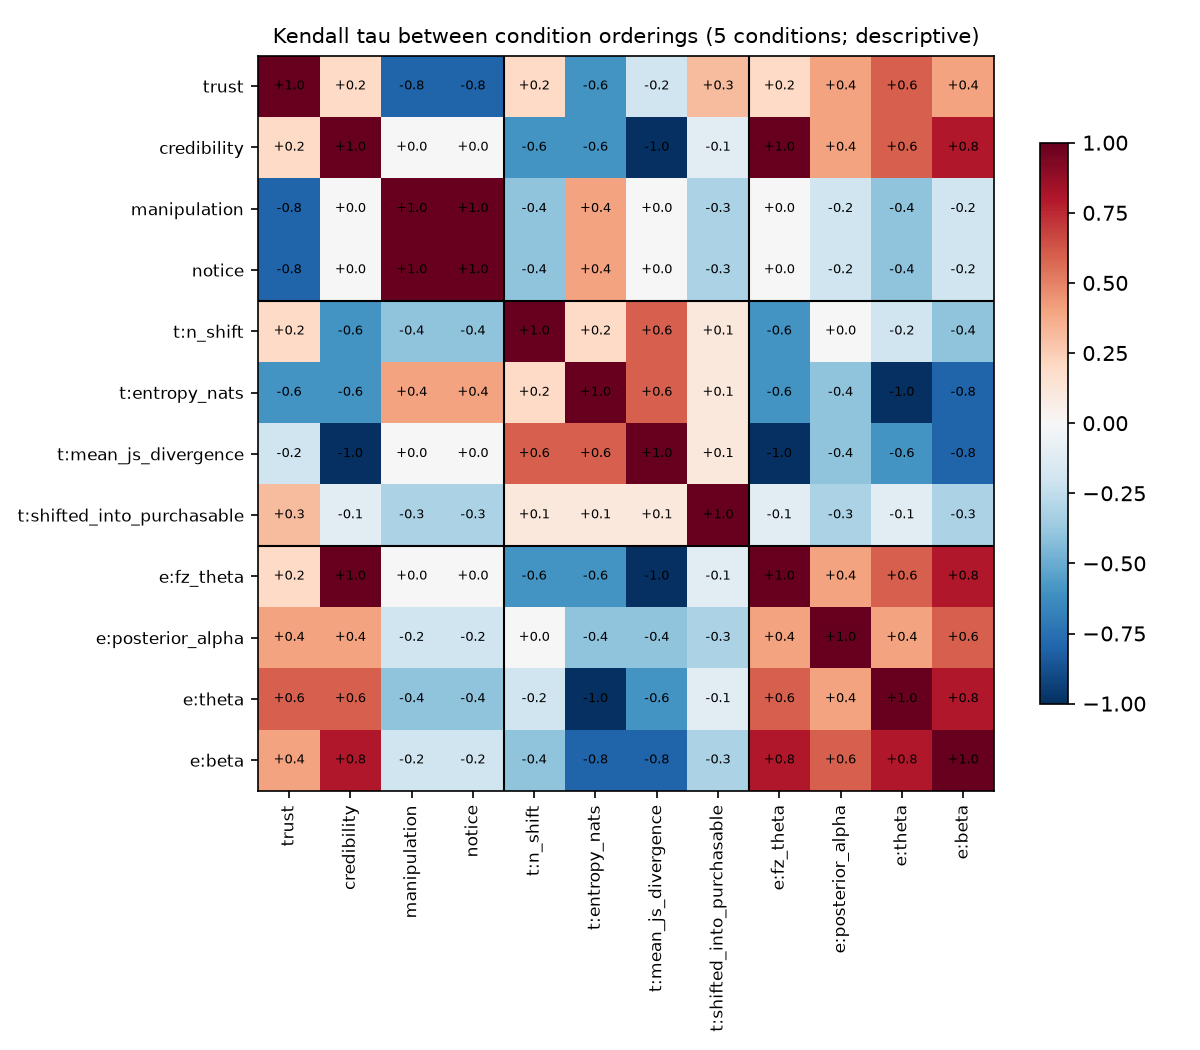

In [10]:
show("concordance/condition_profiles.png", 1300)
show("concordance/kendall_tau_profiles.png", 700)

## Block 7 — write − read EEG trait × behavioural / trajectory ad effects (\(n=18\))

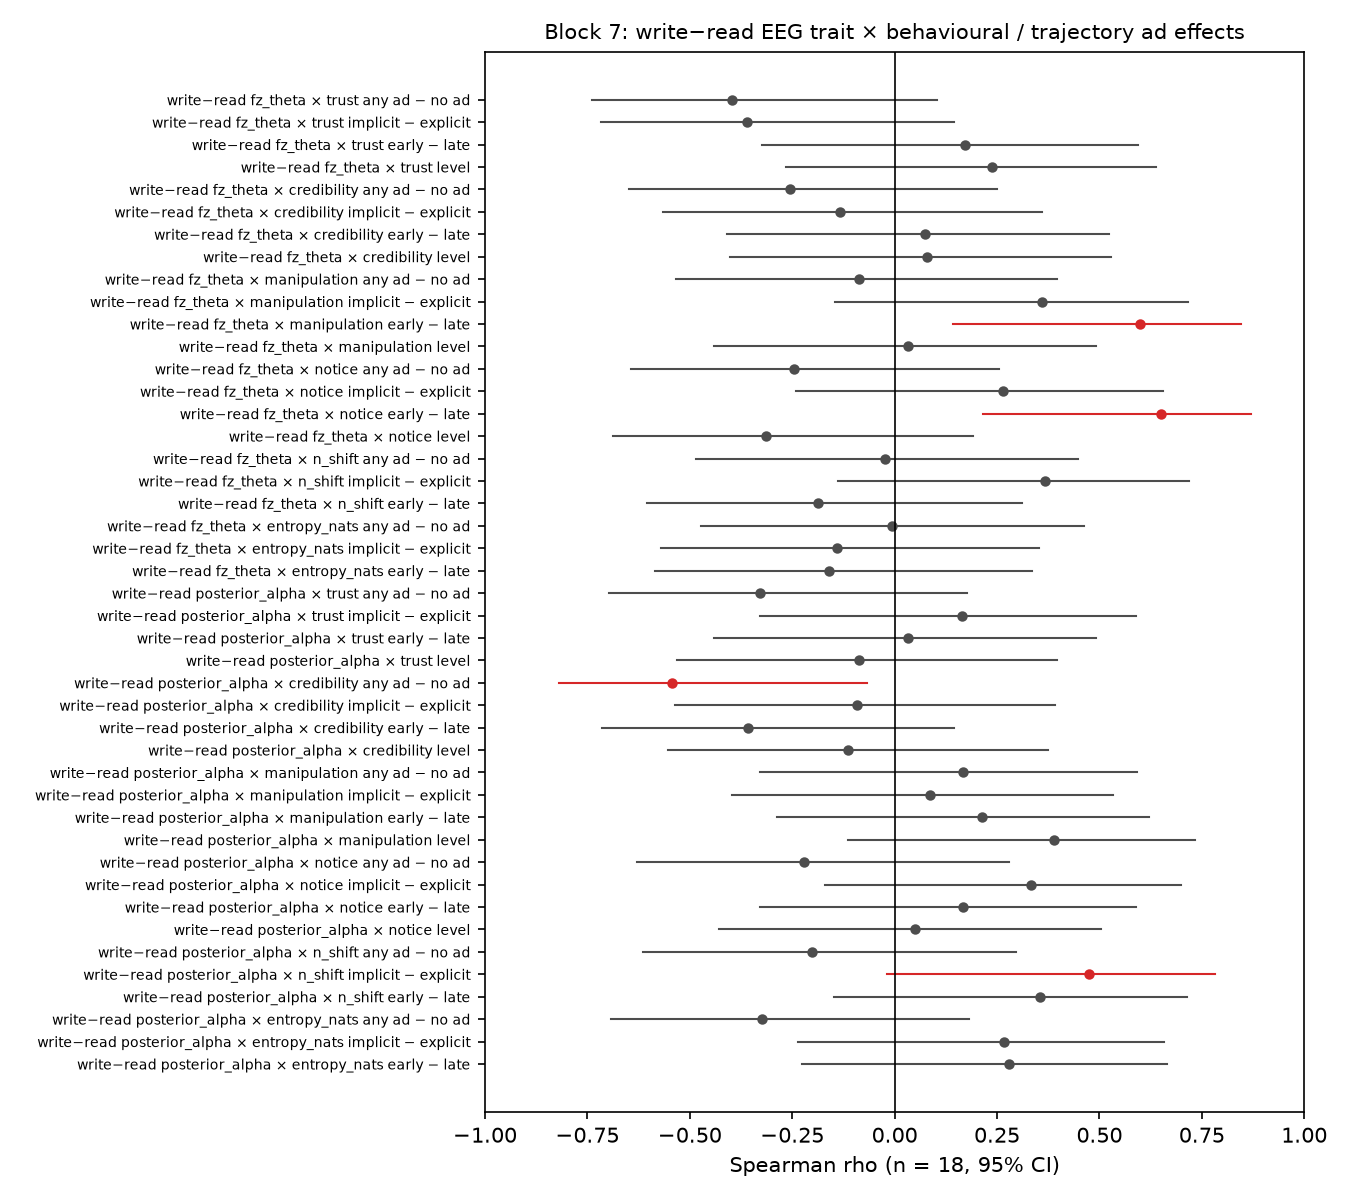

,family,trait,target,contrast,n,rho,ci_lo,ci_hi,p_raw,p_holm_family,loo_sign_stable
0,task_state_x_behaviour,ts_fz_theta,notice,early_vs_late,18,0.650,0.216,0.870,0.003,0.111,True
1,task_state_x_behaviour,ts_fz_theta,manipulation,early_vs_late,18,0.600,0.143,0.846,0.008,0.262,True
2,task_state_x_behaviour,ts_posterior_alpha,credibility,any_ad_vs_no_ads,18,-0.545,-0.819,-0.068,0.019,0.583,True
3,task_state_x_trajectory,ts_posterior_alpha,traj_n_shift,inline_vs_block,18,0.474,-0.019,0.781,0.047,0.564,True
4,task_state_x_behaviour,ts_fz_theta,trust,any_ad_vs_no_ads,18,-0.398,-0.738,0.104,0.102,1.000,True
5,task_state_x_behaviour,ts_posterior_alpha,manipulation,level,18,0.388,-0.114,0.733,0.111,1.000,True


In [11]:
show("task_state/task_state_forest.png", 900)
K = js("task_state/summary.json")
display(pd.DataFrame(K["top"]).round(3))

Nothing after Holm (44 tests). The closest is write−read Fz \(\theta\) × notice early−late \(D\) (\(\rho=.65\), raw .003, Holm .11).

## What this adds to the thesis

1. **A precise, documented cross-modal null with the reasons.** Not "no relation", but: the person-level EEG contrast scores for the primary feature carry no reliable between-person variance; trajectory scores barely agree across classifiers; and \(n=18\) cannot resolve \(|\rho| < .47\). The combos were not powered to find what they looked for, and block 0 says so with numbers rather than an MDE sermon.
2. **The one surviving Dataset A cell is mostly a mean shift** (pair-\(D\) reliability 0 at \(k=37\), upper bound .52; .47 whole-window), consistent with the "tenths of a dB" Dataset A reading; an individual-differences story for it has little to stand on.
3. **Turn- and event-grain nulls** on process and genre movement after an ad, with tight intervals at the turn grain.
4. **A methods note**: GEE with 3 non-events produced two "significant" cells that a within-person permutation dismisses; none of it enters Results.